In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
import math
import os

import statsmodels.formula.api as smf

%load_ext autoreload
%autoreload 2

import utils.columns as cols
import utils.transform as transform
import utils.univariate as univar
import utils.bivariate as bivar
import utils.linear_regression as linear
import utils.experiment as experiment


# Read Preprocessed Mental, Social, and Green Space Datasets

In [2]:
# Define the base directory
BASE_PATH = '../final_data/processed'

# Load datasets using a dictionary comprehension
files = {
    'mental': f'{BASE_PATH}/medical/basis/mental_health_dataset_b.xlsx',
    'social': f'{BASE_PATH}/medical/basis/social_factors_dataset_b.xlsx',
    'green': f'{BASE_PATH}/environmental/basis/green_space_dataset_b.xlsx'
}

datasets = {name: pd.read_excel(path, index_col=0) for name, path in files.items()}

# Combine all datasets at once along the index (columns/horizontal alignment)
data_complete = pd.concat(datasets.values(), axis=1, join='outer')


In [3]:
data_complete = transform.rename_columns(data_complete)

# Age grouping

In [4]:
data_complete['Age_group'] = transform.categorize(
    data_complete, 'Age', bins=[0,40,53,65,np.inf], right=False, labels=["[18, 40)","[40, 53)","[53, 65)","[65, 81)"]
)

# Outcome Direction Map

In [5]:
outcome_direction_map = {
    "CES-D Score":  {"direction": "higher_is_worse", "label": "more severe depressive symptoms"},
    "GAD-7 Score":  {"direction": "higher_is_worse", "label": "more severe anxiety symptoms"},
    "SWLS Score":   {"direction": "higher_is_better", "label": "better life satisfaction"},
}

# Linear Model: Mental Health Scores across Green Exposures

## NDVI – continuous

In [8]:
data = data_complete.copy()

outcomes = cols.mental_numeric
predictors = cols.ndvi

results_df, model_store = experiment.run_linear_grid(
    data                  = data,
    outcomes              = outcomes,
    predictors            = predictors,
    predictor_type        = "continuous",
    scale_predictor       = 0.1,
    outcome_direction_map = outcome_direction_map,
    covariates            = ["Age", "Sex", "Socioeconomic Status (Tiers)"],
)

display(results_df)

  [1/12] CES-D Score × NDVI (100m Buffer)
  [2/12] CES-D Score × NDVI (200m Buffer)
  [3/12] CES-D Score × NDVI (500m Buffer)
  [4/12] CES-D Score × NDVI (1000m Buffer)
  [5/12] GAD-7 Score × NDVI (100m Buffer)
  [6/12] GAD-7 Score × NDVI (200m Buffer)
  [7/12] GAD-7 Score × NDVI (500m Buffer)
  [8/12] GAD-7 Score × NDVI (1000m Buffer)
  [9/12] SWLS Score × NDVI (100m Buffer)
  [10/12] SWLS Score × NDVI (200m Buffer)
  [11/12] SWLS Score × NDVI (500m Buffer)
  [12/12] SWLS Score × NDVI (1000m Buffer)

  Linear grid complete: 12/12 models fitted.


,outcome,predictor,predictor_type,n,outcome_direction,scale_predictor,reference_level,level,beta,SE,CI_lower,CI_upper,beta_95CI,t_stat,p_value,p_value_fmt,covariates
0,CES-D Score,NDVI (100m Buffer),continuous,9117,higher_is_worse,0.1,None,NDVI (100m Buffer),-0.278,0.085,-0.445,-0.111,"-0.278 (-0.445, -0.111)",-3.268,1.086481e-03,0.001,"Age, Sex, Socioeconomic Status (Tiers)"
1,CES-D Score,NDVI (200m Buffer),continuous,9117,higher_is_worse,0.1,None,NDVI (200m Buffer),-0.379,0.089,-0.554,-0.203,"-0.379 (-0.554, -0.203)",-4.232,2.335124e-05,<0.001,"Age, Sex, Socioeconomic Status (Tiers)"
2,CES-D Score,NDVI (500m Buffer),continuous,9117,higher_is_worse,0.1,None,NDVI (500m Buffer),-0.378,0.093,-0.559,-0.197,"-0.378 (-0.559, -0.197)",-4.086,4.430554e-05,<0.001,"Age, Sex, Socioeconomic Status (Tiers)"
3,CES-D Score,NDVI (1000m Buffer),continuous,9117,higher_is_worse,0.1,None,NDVI (1000m Buffer),-0.333,0.098,-0.525,-0.141,"-0.333 (-0.525, -0.141)",-3.393,6.937116e-04,<0.001,"Age, Sex, Socioeconomic Status (Tiers)"
4,GAD-7 Score,NDVI (100m Buffer),continuous,9278,higher_is_worse,0.1,None,NDVI (100m Buffer),-0.058,0.041,-0.139,0.022,"-0.058 (-0.139, 0.022)",-1.426,1.539058e-01,0.154,"Age, Sex, Socioeconomic Status (Tiers)"
5,GAD-7 Score,NDVI (200m Buffer),continuous,9278,higher_is_worse,0.1,None,NDVI (200m Buffer),-0.068,0.043,-0.152,0.016,"-0.068 (-0.152, 0.016)",-1.581,1.139447e-01,0.114,"Age, Sex, Socioeconomic Status (Tiers)"
6,GAD-7 Score,NDVI (500m Buffer),continuous,9278,higher_is_worse,0.1,None,NDVI (500m Buffer),-0.129,0.045,-0.216,-0.041,"-0.129 (-0.216, -0.041)",-2.887,3.892392e-03,0.004,"Age, Sex, Socioeconomic Status (Tiers)"
7,GAD-7 Score,NDVI (1000m Buffer),continuous,9278,higher_is_worse,0.1,None,NDVI (1000m Buffer),-0.137,0.047,-0.230,-0.044,"-0.137 (-0.230, -0.044)",-2.893,3.825436e-03,0.004,"Age, Sex, Socioeconomic Status (Tiers)"
8,SWLS Score,NDVI (100m Buffer),continuous,9297,higher_is_better,0.1,None,NDVI (100m Buffer),0.511,0.066,0.382,0.640,"0.511 (0.382, 0.640)",7.755,9.784476e-15,<0.001,"Age, Sex, Socioeconomic Status (Tiers)"
9,SWLS Score,NDVI (200m Buffer),continuous,9297,higher_is_better,0.1,None,NDVI (200m Buffer),0.610,0.069,0.475,0.746,"0.610 (0.475, 0.746)",8.810,1.478292e-18,<0.001,"Age, Sex, Socioeconomic Status (Tiers)"


## Save Linear Regression results to `linear_results` in `pkl` and `csv`

In [9]:
##out_path = f"outputs/linear/mental_numeric/ndvi/adjusted/linear_results" ## ndvi | quartiles
##experiment.save_results(results_df, model_store, path=out_path)

  Saved pickle : outputs/linear/mental_numeric/ndvi/adjusted/linear_results.pkl
  Saved CSV    : outputs/linear/mental_numeric/ndvi/adjusted/linear_results.csv


## Land-use-based Green Space – Quartiles

In [12]:
data = data_complete.copy()

outcomes = cols.mental_numeric
predictors = cols.greenspace_quartiles

results_df, model_store = experiment.run_linear_grid(
    data                  = data,
    outcomes              = outcomes,
    predictors            = predictors,
    predictor_type        = "categorical",
    reference_category    = "1.0",
    label_mapping         = {"1.0": "Q1", "2.0": "Q2", "3.0": "Q3", "4.0": "Q4"},
    outcome_direction_map = outcome_direction_map,
    covariates            = ["Age", "Sex", "Socioeconomic Status (Tiers)"],
)

display(results_df)

  [1/12] CES-D Score × Green Space Quartile (100m Buffer)
  [2/12] CES-D Score × Green Space Quartile (200m Buffer)
  [3/12] CES-D Score × Green Space Quartile (500m Buffer)
  [4/12] CES-D Score × Green Space Quartile (1000m Buffer)
  [5/12] GAD-7 Score × Green Space Quartile (100m Buffer)
  [6/12] GAD-7 Score × Green Space Quartile (200m Buffer)
  [7/12] GAD-7 Score × Green Space Quartile (500m Buffer)
  [8/12] GAD-7 Score × Green Space Quartile (1000m Buffer)
  [9/12] SWLS Score × Green Space Quartile (100m Buffer)
  [10/12] SWLS Score × Green Space Quartile (200m Buffer)
  [11/12] SWLS Score × Green Space Quartile (500m Buffer)
  [12/12] SWLS Score × Green Space Quartile (1000m Buffer)

  Linear grid complete: 12/12 models fitted.


,outcome,predictor,predictor_type,n,outcome_direction,reference_category,reference_level,level,beta,SE,CI_lower,CI_upper,beta_95CI,t_stat,p_value,p_value_fmt,covariates
0,CES-D Score,Green Space Quartile (100m Buffer),categorical,9079,higher_is_worse,1.0,Q1,Q2,-0.136,0.204,-0.536,0.265,"-0.136 (-0.536, 0.265)",-0.664,5.066516e-01,0.507,"Age, Sex, Socioeconomic Status (Tiers)"
1,CES-D Score,Green Space Quartile (100m Buffer),categorical,9079,higher_is_worse,1.0,Q1,Q3,-0.248,0.205,-0.650,0.154,"-0.248 (-0.650, 0.154)",-1.210,2.262868e-01,0.226,"Age, Sex, Socioeconomic Status (Tiers)"
2,CES-D Score,Green Space Quartile (100m Buffer),categorical,9079,higher_is_worse,1.0,Q1,Q4,-0.543,0.204,-0.942,-0.144,"-0.543 (-0.942, -0.144)",-2.666,7.685447e-03,0.008,"Age, Sex, Socioeconomic Status (Tiers)"
3,CES-D Score,Green Space Quartile (200m Buffer),categorical,9079,higher_is_worse,1.0,Q1,Q2,-0.286,0.204,-0.687,0.114,"-0.286 (-0.687, 0.114)",-1.401,1.611923e-01,0.161,"Age, Sex, Socioeconomic Status (Tiers)"
4,CES-D Score,Green Space Quartile (200m Buffer),categorical,9079,higher_is_worse,1.0,Q1,Q3,-0.628,0.204,-1.028,-0.227,"-0.628 (-1.028, -0.227)",-3.075,2.113432e-03,0.002,"Age, Sex, Socioeconomic Status (Tiers)"
5,CES-D Score,Green Space Quartile (200m Buffer),categorical,9079,higher_is_worse,1.0,Q1,Q4,-0.627,0.203,-1.025,-0.229,"-0.627 (-1.025, -0.229)",-3.088,2.021559e-03,0.002,"Age, Sex, Socioeconomic Status (Tiers)"
6,CES-D Score,Green Space Quartile (500m Buffer),categorical,9079,higher_is_worse,1.0,Q1,Q2,-0.109,0.204,-0.509,0.290,"-0.109 (-0.509, 0.290)",-0.536,5.921992e-01,0.592,"Age, Sex, Socioeconomic Status (Tiers)"
7,CES-D Score,Green Space Quartile (500m Buffer),categorical,9079,higher_is_worse,1.0,Q1,Q3,-0.285,0.203,-0.683,0.114,"-0.285 (-0.683, 0.114)",-1.399,1.618072e-01,0.162,"Age, Sex, Socioeconomic Status (Tiers)"
8,CES-D Score,Green Space Quartile (500m Buffer),categorical,9079,higher_is_worse,1.0,Q1,Q4,-0.438,0.203,-0.836,-0.040,"-0.438 (-0.836, -0.040)",-2.156,3.113393e-02,0.031,"Age, Sex, Socioeconomic Status (Tiers)"
9,CES-D Score,Green Space Quartile (1000m Buffer),categorical,9079,higher_is_worse,1.0,Q1,Q2,-0.108,0.204,-0.507,0.291,"-0.108 (-0.507, 0.291)",-0.531,5.956516e-01,0.596,"Age, Sex, Socioeconomic Status (Tiers)"


## Save Linear Regression results to `linear_results` in `pkl` and `csv`

In [13]:
##out_path = f"outputs/linear/mental_numeric/quartiles/adjusted/linear_results" ## ndvi | quartiles
##experiment.save_results(results_df, model_store, path=out_path)

  Saved pickle : outputs/linear/mental_numeric/quartiles/adjusted/linear_results.pkl
  Saved CSV    : outputs/linear/mental_numeric/quartiles/adjusted/linear_results.csv


# Load Linear Model results from `linear_results.pkl`

In [ ]:
##out_path = f"outputs/linear/mental_numeric/quartiles/adjusted/linear_results" ## ndvi | quartiles
##results_df, model_store = experiment.load_results(out_path)

# Analysis – Mental Scores vs. Green Exposures

## NDVI – Linear model – unadjusted

In [14]:
out_path = f"outputs/linear/mental_numeric/ndvi/unadjusted/linear_results"
results_df, model_store = experiment.load_results(out_path)

outcome = cols.mental_numeric
predictor = cols.ndvi[2]

columns = ["outcome", "predictor", "predictor_type", "n", "scale_predictor", 
           "beta", "beta_95CI", "SE", "t_stat", "p_value_fmt", "covariates"]

#results_df.query(f"outcome == @outcome and predictor == @predictor and level == 'Q4'")[columns]
results_df.query(f"outcome == @outcome and predictor == @predictor")[columns]

  Loaded results saved at: 2026-07-27T15:32:26.434941


,outcome,predictor,predictor_type,n,scale_predictor,beta,beta_95CI,SE,t_stat,p_value_fmt,covariates
2,CES-D Score,NDVI (500m Buffer),continuous,9142,0.1,-0.413,"-0.413 (-0.600, -0.227)",0.095,-4.338,<0.001,unadjusted
6,GAD-7 Score,NDVI (500m Buffer),continuous,9304,0.1,-0.162,"-0.162 (-0.251, -0.074)",0.045,-3.590,<0.001,unadjusted
10,SWLS Score,NDVI (500m Buffer),continuous,9323,0.1,0.679,"0.679 (0.534, 0.824)",0.074,9.186,<0.001,unadjusted


## NDVI – Linear model – adjusted: Sex, Age, SES

In [15]:
out_path = f"outputs/linear/mental_numeric/ndvi/adjusted/linear_results"
results_df, model_store = experiment.load_results(out_path)

outcome = cols.mental_numeric
predictor = cols.ndvi[2]

columns = ["outcome", "predictor", "predictor_type", "n", "scale_predictor", 
           "beta", "beta_95CI", "SE", "t_stat", "p_value_fmt", "covariates"]

results_df.query(f"outcome == @outcome and predictor == @predictor")[columns]

  Loaded results saved at: 2026-07-27T15:32:39.888454


,outcome,predictor,predictor_type,n,scale_predictor,beta,beta_95CI,SE,t_stat,p_value_fmt,covariates
2,CES-D Score,NDVI (500m Buffer),continuous,9117,0.1,-0.378,"-0.378 (-0.559, -0.197)",0.093,-4.086,<0.001,"Age, Sex, Socioeconomic Status (Tiers)"
6,GAD-7 Score,NDVI (500m Buffer),continuous,9278,0.1,-0.129,"-0.129 (-0.216, -0.041)",0.045,-2.887,0.004,"Age, Sex, Socioeconomic Status (Tiers)"
10,SWLS Score,NDVI (500m Buffer),continuous,9297,0.1,0.561,"0.561 (0.420, 0.702)",0.072,7.809,<0.001,"Age, Sex, Socioeconomic Status (Tiers)"


## Land-use-based Quartiles – Linear model – unadjusted

In [16]:
out_path = f"outputs/linear/mental_numeric/quartiles/unadjusted/linear_results"
results_df, model_store = experiment.load_results(out_path)

outcome = cols.mental_numeric
predictor = cols.greenspace_quartiles[2]

columns = ["outcome", "predictor", "predictor_type", "n", "reference_level", "level", 
           "beta", "beta_95CI", "SE", "t_stat", "p_value_fmt", "covariates"]

results_df.query(f"outcome == @outcome and predictor == @predictor and level == 'Q4'")[columns]

  Loaded results saved at: 2026-07-27T15:33:22.144336


,outcome,predictor,predictor_type,n,reference_level,level,beta,beta_95CI,SE,t_stat,p_value_fmt,covariates
8,CES-D Score,Green Space Quartile (500m Buffer),categorical,9104,Q1,Q4,-0.793,"-0.793 (-1.204, -0.383)",0.210,-3.787,<0.001,unadjusted
20,GAD-7 Score,Green Space Quartile (500m Buffer),categorical,9264,Q1,Q4,-0.251,"-0.251 (-0.445, -0.056)",0.099,-2.523,0.012,unadjusted
32,SWLS Score,Green Space Quartile (500m Buffer),categorical,9283,Q1,Q4,1.480,"1.480 (1.161, 1.798)",0.162,9.117,<0.001,unadjusted


## Land-use-based Quartiles – Linear model – adjusted: Sex, Age, SES

In [17]:
out_path = f"outputs/linear/mental_numeric/quartiles/adjusted/linear_results"
results_df, model_store = experiment.load_results(out_path)

outcome = cols.mental_numeric
predictor = cols.greenspace_quartiles[2]

columns = ["outcome", "predictor", "predictor_type", "n", "reference_level", "level", 
           "beta", "beta_95CI", "SE", "t_stat", "p_value_fmt", "covariates"]

results_df.query(f"outcome == @outcome and predictor == @predictor and level == 'Q4'")[columns]

  Loaded results saved at: 2026-07-27T15:33:55.488972


,outcome,predictor,predictor_type,n,reference_level,level,beta,beta_95CI,SE,t_stat,p_value_fmt,covariates
8,CES-D Score,Green Space Quartile (500m Buffer),categorical,9079,Q1,Q4,-0.438,"-0.438 (-0.836, -0.040)",0.203,-2.156,0.031,"Age, Sex, Socioeconomic Status (Tiers)"
20,GAD-7 Score,Green Space Quartile (500m Buffer),categorical,9238,Q1,Q4,-0.148,"-0.148 (-0.340, 0.044)",0.098,-1.507,0.132,"Age, Sex, Socioeconomic Status (Tiers)"
32,SWLS Score,Green Space Quartile (500m Buffer),categorical,9257,Q1,Q4,1.156,"1.156 (0.847, 1.465)",0.158,7.330,<0.001,"Age, Sex, Socioeconomic Status (Tiers)"


# Plot FOREST – Mental Scores vs. Green Exposure Quartiles

  Loaded results saved at: 2026-07-27T15:33:22.144336


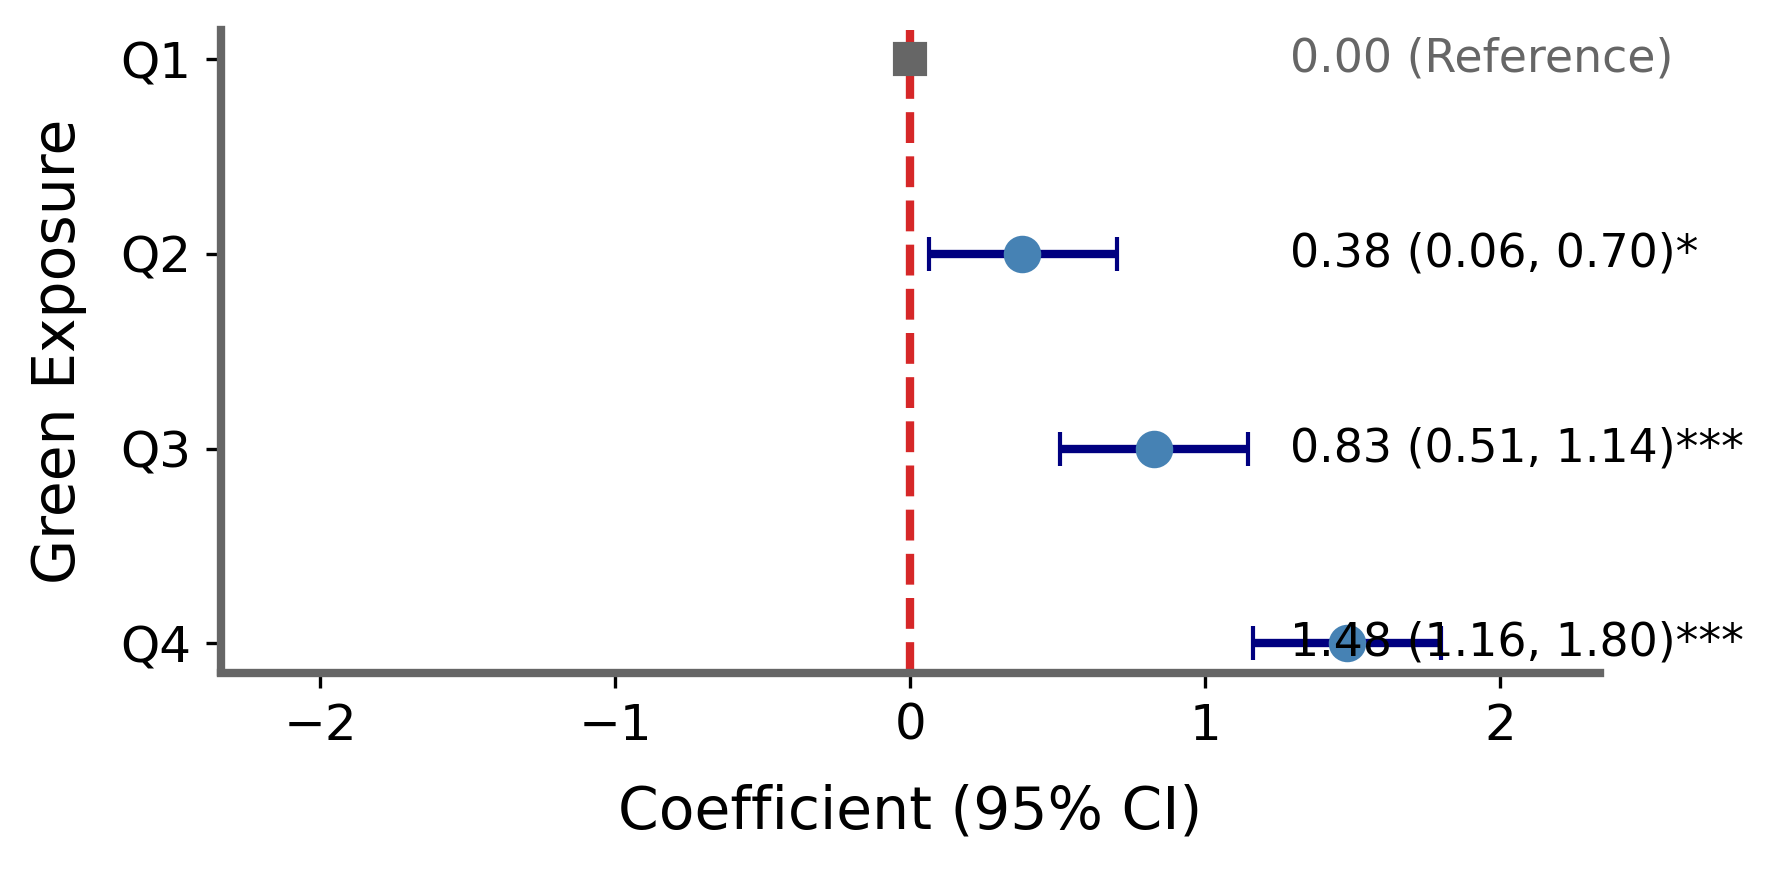

In [18]:
out_path = f"outputs/linear/mental_numeric/quartiles/unadjusted/linear_results"
results_df, model_store = experiment.load_results(out_path)

outcome = cols.mental_numeric[2]
predictor = cols.greenspace_quartiles[2]
df_plot = results_df.query(f"outcome == @outcome and predictor == @predictor")
linear.plot_forest(df_plot)#, save_path='out.png')

# Linear Model – Single Mental Health Variable

In [19]:
data = data_complete.copy()

outcome = cols.mental_numeric[2]
predictor = cols.greenspace_quartiles[1]
#predictor = cols.ndvi[2]

result, metadata = linear.fit_model(data, outcome, predictor, predictor_type="categorical")#, covariates=['Sex', 'Age'])

In [20]:
results_df = linear.extract_results(
    result,
    metadata
)
print(f"outcome: {metadata['outcome']}, \npredictor: {metadata['predictor']}")
display(results_df)

outcome: SWLS Score, 
predictor: Green Space Quartile (200m Buffer)


,reference_level,level,beta,SE,CI_lower,CI_upper,beta_95CI,t_stat,p_value,p_value_fmt,covariates
0,Q1,Q2,0.488,0.162,0.169,0.806,"0.488 (0.169, 0.806)",3.002,2.688949e-03,0.003,unadjusted
1,Q1,Q3,0.861,0.162,0.542,1.179,"0.861 (0.542, 1.179)",5.296,1.210378e-07,<0.001,unadjusted
2,Q1,Q4,1.599,0.162,1.281,1.916,"1.599 (1.281, 1.916)",9.870,7.242793e-23,<0.001,unadjusted


# Stratified Linear Model – Experiments

## SES-stratified: Mental Scores across NDVI

In [31]:
data = data_complete.copy()

outcomes = cols.mental_numeric
predictors = cols.ndvi

strata_results, strata_summary = experiment.run_stratified_grid(
    data                  = data,
    outcomes              = outcomes,
    predictors            = predictors,
    stratify_by           = "Socioeconomic Status (Tiers)",
#    strata                = [1, 2, 3],
    model_type            = "linear",
    predictor_type        = "continuous",
    scale_predictor       = 0.1,
    outcome_direction_map = outcome_direction_map,
    covariates            = ["Sex", "Age"]
)

display(strata_results)

  [1/12] CES-D Score × NDVI (100m Buffer)  [stratified by Socioeconomic Status (Tiers), linear]
  Stratum Socioeconomic Status (Tiers) = 1.0  (n = 1995)
  Stratum Socioeconomic Status (Tiers) = 2.0  (n = 5994)
  Stratum Socioeconomic Status (Tiers) = 3.0  (n = 1974)
  [2/12] CES-D Score × NDVI (200m Buffer)  [stratified by Socioeconomic Status (Tiers), linear]
  Stratum Socioeconomic Status (Tiers) = 1.0  (n = 1995)
  Stratum Socioeconomic Status (Tiers) = 2.0  (n = 5994)
  Stratum Socioeconomic Status (Tiers) = 3.0  (n = 1974)
  [3/12] CES-D Score × NDVI (500m Buffer)  [stratified by Socioeconomic Status (Tiers), linear]
  Stratum Socioeconomic Status (Tiers) = 1.0  (n = 1995)
  Stratum Socioeconomic Status (Tiers) = 2.0  (n = 5994)
  Stratum Socioeconomic Status (Tiers) = 3.0  (n = 1974)
  [4/12] CES-D Score × NDVI (1000m Buffer)  [stratified by Socioeconomic Status (Tiers), linear]
  Stratum Socioeconomic Status (Tiers) = 1.0  (n = 1995)
  Stratum Socioeconomic Status (Tiers) = 2.0 

,outcome,predictor,predictor_type,n,stratum_var,stratum,outcome_direction,scale_predictor,reference_level,level,beta,SE,CI_lower,CI_upper,beta_95CI,t_stat,p_value,p_value_fmt,covariates
0,CES-D Score,NDVI (100m Buffer),continuous,1798,Socioeconomic Status (Tiers),1.0,higher_is_worse,0.1,None,NDVI (100m Buffer),-0.219,0.222,-0.655,0.217,"-0.219 (-0.655, 0.217)",-0.986,3.241038e-01,0.324,"Sex, Age"
1,CES-D Score,NDVI (100m Buffer),continuous,5475,Socioeconomic Status (Tiers),2.0,higher_is_worse,0.1,None,NDVI (100m Buffer),-0.249,0.109,-0.463,-0.035,"-0.249 (-0.463, -0.035)",-2.279,2.271692e-02,0.023,"Sex, Age"
2,CES-D Score,NDVI (100m Buffer),continuous,1844,Socioeconomic Status (Tiers),3.0,higher_is_worse,0.1,None,NDVI (100m Buffer),-0.369,0.161,-0.686,-0.053,"-0.369 (-0.686, -0.053)",-2.288,2.223299e-02,0.022,"Sex, Age"
3,CES-D Score,NDVI (200m Buffer),continuous,1798,Socioeconomic Status (Tiers),1.0,higher_is_worse,0.1,None,NDVI (200m Buffer),-0.405,0.237,-0.870,0.059,"-0.405 (-0.870, 0.059)",-1.712,8.712441e-02,0.087,"Sex, Age"
4,CES-D Score,NDVI (200m Buffer),continuous,5475,Socioeconomic Status (Tiers),2.0,higher_is_worse,0.1,None,NDVI (200m Buffer),-0.361,0.115,-0.586,-0.136,"-0.361 (-0.586, -0.136)",-3.145,1.670505e-03,0.002,"Sex, Age"
5,CES-D Score,NDVI (200m Buffer),continuous,1844,Socioeconomic Status (Tiers),3.0,higher_is_worse,0.1,None,NDVI (200m Buffer),-0.355,0.168,-0.684,-0.026,"-0.355 (-0.684, -0.026)",-2.114,3.465729e-02,0.035,"Sex, Age"
6,CES-D Score,NDVI (500m Buffer),continuous,1798,Socioeconomic Status (Tiers),1.0,higher_is_worse,0.1,None,NDVI (500m Buffer),-0.614,0.249,-1.102,-0.126,"-0.614 (-1.102, -0.126)",-2.468,1.368530e-02,0.014,"Sex, Age"
7,CES-D Score,NDVI (500m Buffer),continuous,5475,Socioeconomic Status (Tiers),2.0,higher_is_worse,0.1,None,NDVI (500m Buffer),-0.352,0.118,-0.583,-0.121,"-0.352 (-0.583, -0.121)",-2.992,2.782840e-03,0.003,"Sex, Age"
8,CES-D Score,NDVI (500m Buffer),continuous,1844,Socioeconomic Status (Tiers),3.0,higher_is_worse,0.1,None,NDVI (500m Buffer),-0.224,0.174,-0.566,0.118,"-0.224 (-0.566, 0.118)",-1.285,1.990873e-01,0.199,"Sex, Age"
9,CES-D Score,NDVI (1000m Buffer),continuous,1798,Socioeconomic Status (Tiers),1.0,higher_is_worse,0.1,None,NDVI (1000m Buffer),-0.677,0.265,-1.197,-0.156,"-0.677 (-1.197, -0.156)",-2.551,1.083772e-02,0.011,"Sex, Age"


## Save Stratified Regression results to `linear_results` in `pkl` and `csv`

In [32]:
##out_path = f"outputs/linear/stratified_ses/mental_numeric/ndvi/adjusted/linear_results"
##experiment.save_results(strata_results, strata_summary, path=out_path)

  Saved pickle : outputs/linear/stratified_ses/mental_numeric/ndvi/adjusted/linear_results.pkl
  Saved CSV    : outputs/linear/stratified_ses/mental_numeric/ndvi/adjusted/linear_results.csv


## SES-Stratified: Mental Scores across Green Space Quartiles

In [43]:
data = data_complete.copy()

outcomes = cols.mental_numeric
predictors = cols.greenspace_quartiles

strata_results, strata_summary = experiment.run_stratified_grid(
    data                  = data,
    outcomes              = outcomes,
    predictors            = predictors,
    stratify_by           = "Socioeconomic Status (Tiers)",
#    strata                = [1, 2, 3],
    model_type            = "linear",
    predictor_type        = "categorical",
    reference_category    = "1.0",
    label_mapping         = {"1.0": "Q1", "2.0": "Q2", "3.0": "Q3", "4.0": "Q4"},
    outcome_direction_map = outcome_direction_map,
    covariates            = ["Sex", "Age"]
)

display(strata_results)

  [1/12] CES-D Score × Green Space Quartile (100m Buffer)  [stratified by Socioeconomic Status (Tiers), linear]
  Stratum Socioeconomic Status (Tiers) = 1.0  (n = 1995)
  Stratum Socioeconomic Status (Tiers) = 2.0  (n = 5994)
  Stratum Socioeconomic Status (Tiers) = 3.0  (n = 1974)
  [2/12] CES-D Score × Green Space Quartile (200m Buffer)  [stratified by Socioeconomic Status (Tiers), linear]
  Stratum Socioeconomic Status (Tiers) = 1.0  (n = 1995)
  Stratum Socioeconomic Status (Tiers) = 2.0  (n = 5994)
  Stratum Socioeconomic Status (Tiers) = 3.0  (n = 1974)
  [3/12] CES-D Score × Green Space Quartile (500m Buffer)  [stratified by Socioeconomic Status (Tiers), linear]
  Stratum Socioeconomic Status (Tiers) = 1.0  (n = 1995)
  Stratum Socioeconomic Status (Tiers) = 2.0  (n = 5994)
  Stratum Socioeconomic Status (Tiers) = 3.0  (n = 1974)
  [4/12] CES-D Score × Green Space Quartile (1000m Buffer)  [stratified by Socioeconomic Status (Tiers), linear]
  Stratum Socioeconomic Status (Tiers)

,outcome,predictor,predictor_type,n,stratum_var,stratum,outcome_direction,reference_category,reference_level,level,beta,SE,CI_lower,CI_upper,beta_95CI,t_stat,p_value,p_value_fmt,covariates
0,CES-D Score,Green Space Quartile (100m Buffer),categorical,1788,Socioeconomic Status (Tiers),1.0,higher_is_worse,1.0,Q1,Q2,0.426,0.509,-0.572,1.425,"0.426 (-0.572, 1.425)",0.838,4.022991e-01,0.402,"Sex, Age"
1,CES-D Score,Green Space Quartile (100m Buffer),categorical,1788,Socioeconomic Status (Tiers),1.0,higher_is_worse,1.0,Q1,Q3,-0.284,0.529,-1.322,0.754,"-0.284 (-1.322, 0.754)",-0.536,5.917508e-01,0.592,"Sex, Age"
2,CES-D Score,Green Space Quartile (100m Buffer),categorical,1788,Socioeconomic Status (Tiers),1.0,higher_is_worse,1.0,Q1,Q4,-0.633,0.554,-1.720,0.453,"-0.633 (-1.720, 0.453)",-1.144,2.528503e-01,0.253,"Sex, Age"
3,CES-D Score,Green Space Quartile (100m Buffer),categorical,5449,Socioeconomic Status (Tiers),2.0,higher_is_worse,1.0,Q1,Q2,-0.404,0.258,-0.911,0.103,"-0.404 (-0.911, 0.103)",-1.563,1.180175e-01,0.118,"Sex, Age"
4,CES-D Score,Green Space Quartile (100m Buffer),categorical,5449,Socioeconomic Status (Tiers),2.0,higher_is_worse,1.0,Q1,Q3,-0.234,0.257,-0.738,0.271,"-0.234 (-0.738, 0.271)",-0.908,3.637219e-01,0.364,"Sex, Age"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
103,SWLS Score,Green Space Quartile (1000m Buffer),categorical,5564,Socioeconomic Status (Tiers),2.0,higher_is_better,1.0,Q1,Q3,0.402,0.197,0.015,0.788,"0.402 (0.015, 0.788)",2.035,4.192165e-02,0.042,"Sex, Age"
104,SWLS Score,Green Space Quartile (1000m Buffer),categorical,5564,Socioeconomic Status (Tiers),2.0,higher_is_better,1.0,Q1,Q4,1.345,0.195,0.964,1.727,"1.345 (0.964, 1.727)",6.906,5.533972e-12,<0.001,"Sex, Age"
105,SWLS Score,Green Space Quartile (1000m Buffer),categorical,1868,Socioeconomic Status (Tiers),3.0,higher_is_better,1.0,Q1,Q2,0.156,0.318,-0.467,0.779,"0.156 (-0.467, 0.779)",0.491,6.232898e-01,0.623,"Sex, Age"
106,SWLS Score,Green Space Quartile (1000m Buffer),categorical,1868,Socioeconomic Status (Tiers),3.0,higher_is_better,1.0,Q1,Q3,0.410,0.299,-0.175,0.996,"0.410 (-0.175, 0.996)",1.375,1.694224e-01,0.169,"Sex, Age"


## Save Stratified Regression results to `linear_results` in `pkl` and `csv`

In [44]:
##out_path = f"outputs/linear/stratified_ses/mental_numeric/quartiles/adjusted/linear_results"
##experiment.save_results(strata_results, strata_summary, path=out_path)

  Saved pickle : outputs/linear/stratified_ses/mental_numeric/quartiles/adjusted/linear_results.pkl
  Saved CSV    : outputs/linear/stratified_ses/mental_numeric/quartiles/adjusted/linear_results.csv


# Analysis – SES-Stratified Linear Model

## Mental Scores vs. NDVI – unadjusted

In [45]:
out_path = f"outputs/linear/stratified_ses/mental_numeric/ndvi/unadjusted/linear_results"
strata_results, strata_summary = experiment.load_results(out_path)

outcome = cols.mental_numeric
predictor = cols.ndvi[2]

columns = ["outcome", "predictor", "n", "stratum_var", "stratum", "scale_predictor",
           "beta", "beta_95CI", "SE", "t_stat", "p_value_fmt", "covariates"]

strata_results.query(f"outcome == @outcome and predictor == @predictor")[columns]

  Loaded results saved at: 2026-07-27T15:40:49.699804


,outcome,predictor,n,stratum_var,stratum,scale_predictor,beta,beta_95CI,SE,t_stat,p_value_fmt,covariates
6,CES-D Score,NDVI (500m Buffer),1798,Socioeconomic Status (Tiers),1.0,0.1,-0.706,"-0.706 (-1.196, -0.216)",0.250,-2.826,0.005,unadjusted
7,CES-D Score,NDVI (500m Buffer),5475,Socioeconomic Status (Tiers),2.0,0.1,-0.290,"-0.290 (-0.522, -0.059)",0.118,-2.456,0.014,unadjusted
8,CES-D Score,NDVI (500m Buffer),1844,Socioeconomic Status (Tiers),3.0,0.1,-0.210,"-0.210 (-0.552, 0.132)",0.174,-1.205,0.229,unadjusted
18,GAD-7 Score,NDVI (500m Buffer),1842,Socioeconomic Status (Tiers),1.0,0.1,-0.342,"-0.342 (-0.577, -0.108)",0.120,-2.864,0.004,unadjusted
19,GAD-7 Score,NDVI (500m Buffer),5573,Socioeconomic Status (Tiers),2.0,0.1,-0.118,"-0.118 (-0.231, -0.004)",0.058,-2.037,0.042,unadjusted
20,GAD-7 Score,NDVI (500m Buffer),1863,Socioeconomic Status (Tiers),3.0,0.1,-0.071,"-0.071 (-0.234, 0.092)",0.083,-0.858,0.391,unadjusted
30,SWLS Score,NDVI (500m Buffer),1836,Socioeconomic Status (Tiers),1.0,0.1,0.577,"0.577 (0.183, 0.971)",0.201,2.870,0.004,unadjusted
31,SWLS Score,NDVI (500m Buffer),5591,Socioeconomic Status (Tiers),2.0,0.1,0.723,"0.723 (0.545, 0.901)",0.091,7.974,<0.001,unadjusted
32,SWLS Score,NDVI (500m Buffer),1870,Socioeconomic Status (Tiers),3.0,0.1,0.385,"0.385 (0.131, 0.639)",0.130,2.968,0.003,unadjusted


## Mental Scores vs. NDVI – adjusted: Sex, Age

In [46]:
out_path = f"outputs/linear/stratified_ses/mental_numeric/ndvi/adjusted/linear_results"
strata_results, strata_summary = experiment.load_results(out_path)

outcome = cols.mental_numeric
predictor = cols.ndvi[2]

columns = ["outcome", "predictor", "n", "stratum_var", "stratum", "scale_predictor",
           "beta", "beta_95CI", "SE", "t_stat", "p_value_fmt", "covariates"]

strata_results.query(f"outcome == @outcome and predictor == @predictor")[columns]

  Loaded results saved at: 2026-07-27T15:41:17.065356


,outcome,predictor,n,stratum_var,stratum,scale_predictor,beta,beta_95CI,SE,t_stat,p_value_fmt,covariates
6,CES-D Score,NDVI (500m Buffer),1798,Socioeconomic Status (Tiers),1.0,0.1,-0.614,"-0.614 (-1.102, -0.126)",0.249,-2.468,0.014,"Sex, Age"
7,CES-D Score,NDVI (500m Buffer),5475,Socioeconomic Status (Tiers),2.0,0.1,-0.352,"-0.352 (-0.583, -0.121)",0.118,-2.992,0.003,"Sex, Age"
8,CES-D Score,NDVI (500m Buffer),1844,Socioeconomic Status (Tiers),3.0,0.1,-0.224,"-0.224 (-0.566, 0.118)",0.174,-1.285,0.199,"Sex, Age"
18,GAD-7 Score,NDVI (500m Buffer),1842,Socioeconomic Status (Tiers),1.0,0.1,-0.279,"-0.279 (-0.510, -0.047)",0.118,-2.360,0.018,"Sex, Age"
19,GAD-7 Score,NDVI (500m Buffer),5573,Socioeconomic Status (Tiers),2.0,0.1,-0.102,"-0.102 (-0.215, 0.011)",0.058,-1.769,0.077,"Sex, Age"
20,GAD-7 Score,NDVI (500m Buffer),1863,Socioeconomic Status (Tiers),3.0,0.1,-0.063,"-0.063 (-0.224, 0.098)",0.082,-0.768,0.442,"Sex, Age"
30,SWLS Score,NDVI (500m Buffer),1836,Socioeconomic Status (Tiers),1.0,0.1,0.383,"0.383 (0.002, 0.763)",0.194,1.973,0.049,"Sex, Age"
31,SWLS Score,NDVI (500m Buffer),5591,Socioeconomic Status (Tiers),2.0,0.1,0.667,"0.667 (0.489, 0.845)",0.091,7.328,<0.001,"Sex, Age"
32,SWLS Score,NDVI (500m Buffer),1870,Socioeconomic Status (Tiers),3.0,0.1,0.390,"0.390 (0.136, 0.645)",0.130,3.006,0.003,"Sex, Age"


## Mental Scores vs. Land-use-based Quartiles – unadjusted

In [47]:
out_path = f"outputs/linear/stratified_ses/mental_numeric/quartiles/unadjusted/linear_results"
strata_results, strata_summary = experiment.load_results(out_path)

outcome = cols.mental_numeric
predictor = cols.greenspace_quartiles[2]

columns = ["outcome", "predictor", "n", "stratum_var", "stratum", "reference_level", "level",  
           "beta", "beta_95CI", "SE", "t_stat", "p_value_fmt", "covariates"]

strata_results.query(f"outcome == @outcome and predictor == @predictor and level == 'Q4'")[columns]

  Loaded results saved at: 2026-07-27T15:45:36.284648


,outcome,predictor,n,stratum_var,stratum,reference_level,level,beta,beta_95CI,SE,t_stat,p_value_fmt,covariates
20,CES-D Score,Green Space Quartile (500m Buffer),1788,Socioeconomic Status (Tiers),1.0,Q1,Q4,-1.811,"-1.811 (-2.927, -0.695)",0.569,-3.184,0.001,unadjusted
23,CES-D Score,Green Space Quartile (500m Buffer),5449,Socioeconomic Status (Tiers),2.0,Q1,Q4,-0.190,"-0.190 (-0.693, 0.314)",0.257,-0.739,0.460,unadjusted
26,CES-D Score,Green Space Quartile (500m Buffer),1842,Socioeconomic Status (Tiers),3.0,Q1,Q4,-0.133,"-0.133 (-0.905, 0.638)",0.393,-0.339,0.734,unadjusted
56,GAD-7 Score,Green Space Quartile (500m Buffer),1831,Socioeconomic Status (Tiers),1.0,Q1,Q4,-0.940,"-0.940 (-1.477, -0.404)",0.274,-3.435,<0.001,unadjusted
59,GAD-7 Score,Green Space Quartile (500m Buffer),5546,Socioeconomic Status (Tiers),2.0,Q1,Q4,-0.004,"-0.004 (-0.251, 0.242)",0.126,-0.034,0.973,unadjusted
62,GAD-7 Score,Green Space Quartile (500m Buffer),1861,Socioeconomic Status (Tiers),3.0,Q1,Q4,-0.086,"-0.086 (-0.452, 0.280)",0.187,-0.460,0.645,unadjusted
92,SWLS Score,Green Space Quartile (500m Buffer),1825,Socioeconomic Status (Tiers),1.0,Q1,Q4,1.652,"1.652 (0.750, 2.554)",0.460,3.591,<0.001,unadjusted
95,SWLS Score,Green Space Quartile (500m Buffer),5564,Socioeconomic Status (Tiers),2.0,Q1,Q4,1.297,"1.297 (0.910, 1.684)",0.197,6.568,<0.001,unadjusted
98,SWLS Score,Green Space Quartile (500m Buffer),1868,Socioeconomic Status (Tiers),3.0,Q1,Q4,0.709,"0.709 (0.138, 1.279)",0.291,2.437,0.015,unadjusted


## Mental Scores vs. Land-use-based Quartiles – adjusted: Sex, Age

In [48]:
out_path = f"outputs/linear/stratified_ses/mental_numeric/quartiles/adjusted/linear_results"
strata_results, strata_summary = experiment.load_results(out_path)

outcome = cols.mental_numeric
predictor = cols.greenspace_quartiles[2]

columns = ["outcome", "predictor", "n", "stratum_var", "stratum", "reference_level", "level",  
           "beta", "beta_95CI", "SE", "t_stat", "p_value_fmt", "covariates"]

strata_results.query(f"outcome == @outcome and predictor == @predictor and level == 'Q4'")[columns]

  Loaded results saved at: 2026-07-27T15:45:56.416802


,outcome,predictor,n,stratum_var,stratum,reference_level,level,beta,beta_95CI,SE,t_stat,p_value_fmt,covariates
20,CES-D Score,Green Space Quartile (500m Buffer),1788,Socioeconomic Status (Tiers),1.0,Q1,Q4,-1.609,"-1.609 (-2.717, -0.500)",0.565,-2.847,0.004,"Sex, Age"
23,CES-D Score,Green Space Quartile (500m Buffer),5449,Socioeconomic Status (Tiers),2.0,Q1,Q4,-0.203,"-0.203 (-0.702, 0.295)",0.254,-0.801,0.423,"Sex, Age"
26,CES-D Score,Green Space Quartile (500m Buffer),1842,Socioeconomic Status (Tiers),3.0,Q1,Q4,-0.174,"-0.174 (-0.943, 0.596)",0.392,-0.443,0.658,"Sex, Age"
56,GAD-7 Score,Green Space Quartile (500m Buffer),1831,Socioeconomic Status (Tiers),1.0,Q1,Q4,-0.804,"-0.804 (-1.334, -0.275)",0.270,-2.978,0.003,"Sex, Age"
59,GAD-7 Score,Green Space Quartile (500m Buffer),5546,Socioeconomic Status (Tiers),2.0,Q1,Q4,0.026,"0.026 (-0.218, 0.269)",0.124,0.206,0.837,"Sex, Age"
62,GAD-7 Score,Green Space Quartile (500m Buffer),1861,Socioeconomic Status (Tiers),3.0,Q1,Q4,-0.116,"-0.116 (-0.477, 0.245)",0.184,-0.629,0.529,"Sex, Age"
92,SWLS Score,Green Space Quartile (500m Buffer),1825,Socioeconomic Status (Tiers),1.0,Q1,Q4,1.284,"1.284 (0.414, 2.153)",0.443,2.896,0.004,"Sex, Age"
95,SWLS Score,Green Space Quartile (500m Buffer),5564,Socioeconomic Status (Tiers),2.0,Q1,Q4,1.266,"1.266 (0.880, 1.652)",0.197,6.432,<0.001,"Sex, Age"
98,SWLS Score,Green Space Quartile (500m Buffer),1868,Socioeconomic Status (Tiers),3.0,Q1,Q4,0.691,"0.691 (0.121, 1.260)",0.290,2.378,0.017,"Sex, Age"


# Analysis – Age-Stratified Linear Model

## Mental Scores vs. NDVI – unadjusted

In [49]:
out_path = f"outputs/linear/stratified_age/mental_numeric/ndvi/unadjusted/linear_results"
strata_results, strata_summary = experiment.load_results(out_path)

outcome = cols.mental_numeric
predictor = cols.ndvi[2]

columns = ["outcome", "predictor", "n", "stratum_var", "stratum", "scale_predictor",
           "beta", "beta_95CI", "SE", "t_stat", "p_value_fmt", "covariates"]

strata_results.query(f"outcome == @outcome and predictor == @predictor")[columns]

  Loaded results saved at: 2026-07-27T15:37:26.048443


,outcome,predictor,n,stratum_var,stratum,scale_predictor,beta,beta_95CI,SE,t_stat,p_value_fmt,covariates
8,CES-D Score,NDVI (500m Buffer),373,Age_group,"[18, 40)",0.1,0.048,"0.048 (-0.893, 0.988)",0.478,0.100,0.921,unadjusted
9,CES-D Score,NDVI (500m Buffer),3202,Age_group,"[40, 53)",0.1,-0.379,"-0.379 (-0.703, -0.055)",0.165,-2.295,0.022,unadjusted
10,CES-D Score,NDVI (500m Buffer),2649,Age_group,"[53, 65)",0.1,-0.578,"-0.578 (-0.943, -0.212)",0.186,-3.100,0.002,unadjusted
11,CES-D Score,NDVI (500m Buffer),2918,Age_group,"[65, 81)",0.1,-0.573,"-0.573 (-0.881, -0.265)",0.157,-3.645,<0.001,unadjusted
24,GAD-7 Score,NDVI (500m Buffer),375,Age_group,"[18, 40)",0.1,0.087,"0.087 (-0.328, 0.503)",0.211,0.412,0.680,unadjusted
25,GAD-7 Score,NDVI (500m Buffer),3237,Age_group,"[40, 53)",0.1,-0.167,"-0.167 (-0.318, -0.015)",0.077,-2.159,0.031,unadjusted
26,GAD-7 Score,NDVI (500m Buffer),2711,Age_group,"[53, 65)",0.1,-0.191,"-0.191 (-0.366, -0.016)",0.089,-2.140,0.032,unadjusted
27,GAD-7 Score,NDVI (500m Buffer),2981,Age_group,"[65, 81)",0.1,-0.158,"-0.158 (-0.307, -0.009)",0.076,-2.074,0.038,unadjusted
40,SWLS Score,NDVI (500m Buffer),377,Age_group,"[18, 40)",0.1,0.360,"0.360 (-0.323, 1.042)",0.347,1.036,0.301,unadjusted
41,SWLS Score,NDVI (500m Buffer),3241,Age_group,"[40, 53)",0.1,0.922,"0.922 (0.671, 1.172)",0.128,7.208,<0.001,unadjusted


## Mental Scores vs. NDVI – adjusted: Sex, SES

In [50]:
out_path = f"outputs/linear/stratified_age/mental_numeric/ndvi/adjusted/linear_results"
strata_results, strata_summary = experiment.load_results(out_path)

outcome = cols.mental_numeric
predictor = cols.ndvi[2]

columns = ["outcome", "predictor", "n", "stratum_var", "stratum", "scale_predictor",
           "beta", "beta_95CI", "SE", "t_stat", "p_value_fmt", "covariates"]

strata_results.query(f"outcome == @outcome and predictor == @predictor")[columns]

  Loaded results saved at: 2026-07-27T15:38:09.448355


,outcome,predictor,n,stratum_var,stratum,scale_predictor,beta,beta_95CI,SE,t_stat,p_value_fmt,covariates
8,CES-D Score,NDVI (500m Buffer),365,Age_group,"[18, 40)",0.1,-0.031,"-0.031 (-0.962, 0.899)",0.473,-0.066,0.947,"Socioeconomic Status (Tiers), Sex"
9,CES-D Score,NDVI (500m Buffer),3199,Age_group,"[40, 53)",0.1,-0.319,"-0.319 (-0.631, -0.007)",0.159,-2.008,0.045,"Socioeconomic Status (Tiers), Sex"
10,CES-D Score,NDVI (500m Buffer),2644,Age_group,"[53, 65)",0.1,-0.450,"-0.450 (-0.802, -0.098)",0.180,-2.505,0.012,"Socioeconomic Status (Tiers), Sex"
11,CES-D Score,NDVI (500m Buffer),2909,Age_group,"[65, 81)",0.1,-0.496,"-0.496 (-0.796, -0.196)",0.153,-3.240,0.001,"Socioeconomic Status (Tiers), Sex"
24,GAD-7 Score,NDVI (500m Buffer),367,Age_group,"[18, 40)",0.1,0.020,"0.020 (-0.389, 0.428)",0.208,0.094,0.925,"Socioeconomic Status (Tiers), Sex"
25,GAD-7 Score,NDVI (500m Buffer),3234,Age_group,"[40, 53)",0.1,-0.150,"-0.150 (-0.299, -0.002)",0.076,-1.986,0.047,"Socioeconomic Status (Tiers), Sex"
26,GAD-7 Score,NDVI (500m Buffer),2706,Age_group,"[53, 65)",0.1,-0.175,"-0.175 (-0.347, -0.002)",0.088,-1.989,0.047,"Socioeconomic Status (Tiers), Sex"
27,GAD-7 Score,NDVI (500m Buffer),2971,Age_group,"[65, 81)",0.1,-0.123,"-0.123 (-0.270, 0.025)",0.075,-1.631,0.103,"Socioeconomic Status (Tiers), Sex"
40,SWLS Score,NDVI (500m Buffer),369,Age_group,"[18, 40)",0.1,0.384,"0.384 (-0.291, 1.059)",0.343,1.119,0.264,"Socioeconomic Status (Tiers), Sex"
41,SWLS Score,NDVI (500m Buffer),3238,Age_group,"[40, 53)",0.1,0.867,"0.867 (0.632, 1.101)",0.120,7.249,<0.001,"Socioeconomic Status (Tiers), Sex"


## Mental Scores vs. Land-use-based Quartiles – unadjusted

In [51]:
out_path = f"outputs/linear/stratified_age/mental_numeric/quartiles/unadjusted/linear_results"
strata_results, strata_summary = experiment.load_results(out_path)

outcome = cols.mental_numeric
predictor = cols.greenspace_quartiles[2]

columns = ["outcome", "predictor", "n", "stratum_var", "stratum", "reference_level", "level",  
           "beta", "beta_95CI", "SE", "t_stat", "p_value_fmt", "covariates"]

strata_results.query(f"outcome == @outcome and predictor == @predictor and level == 'Q4'")[columns]

  Loaded results saved at: 2026-07-27T15:42:35.610135


,outcome,predictor,n,stratum_var,stratum,reference_level,level,beta,beta_95CI,SE,t_stat,p_value_fmt,covariates
26,CES-D Score,Green Space Quartile (500m Buffer),370,Age_group,"[18, 40)",Q1,Q4,1.388,"1.388 (-0.667, 3.442)",1.045,1.328,0.185,unadjusted
29,CES-D Score,Green Space Quartile (500m Buffer),3191,Age_group,"[40, 53)",Q1,Q4,-1.477,"-1.477 (-2.179, -0.775)",0.358,-4.126,<0.001,unadjusted
32,CES-D Score,Green Space Quartile (500m Buffer),2638,Age_group,"[53, 65)",Q1,Q4,-0.491,"-0.491 (-1.290, 0.309)",0.408,-1.204,0.229,unadjusted
35,CES-D Score,Green Space Quartile (500m Buffer),2905,Age_group,"[65, 81)",Q1,Q4,-0.717,"-0.717 (-1.403, -0.031)",0.350,-2.050,0.040,unadjusted
74,GAD-7 Score,Green Space Quartile (500m Buffer),372,Age_group,"[18, 40)",Q1,Q4,0.392,"0.392 (-0.516, 1.301)",0.462,0.849,0.396,unadjusted
77,GAD-7 Score,Green Space Quartile (500m Buffer),3225,Age_group,"[40, 53)",Q1,Q4,-0.550,"-0.550 (-0.879, -0.220)",0.168,-3.271,0.001,unadjusted
80,GAD-7 Score,Green Space Quartile (500m Buffer),2700,Age_group,"[53, 65)",Q1,Q4,-0.173,"-0.173 (-0.553, 0.208)",0.194,-0.890,0.374,unadjusted
83,GAD-7 Score,Green Space Quartile (500m Buffer),2967,Age_group,"[65, 81)",Q1,Q4,-0.065,"-0.065 (-0.397, 0.266)",0.169,-0.386,0.699,unadjusted
122,SWLS Score,Green Space Quartile (500m Buffer),374,Age_group,"[18, 40)",Q1,Q4,0.449,"0.449 (-1.034, 1.933)",0.754,0.596,0.552,unadjusted
125,SWLS Score,Green Space Quartile (500m Buffer),3229,Age_group,"[40, 53)",Q1,Q4,2.350,"2.350 (1.805, 2.895)",0.278,8.457,<0.001,unadjusted


## Mental Scores vs. Land-use-based Quartiles – adjusted: Sex, SES

In [52]:
out_path = f"outputs/linear/stratified_age/mental_numeric/quartiles/adjusted/linear_results"
strata_results, strata_summary = experiment.load_results(out_path)

outcome = cols.mental_numeric
predictor = cols.greenspace_quartiles[2]

columns = ["outcome", "predictor", "n", "stratum_var", "stratum", "reference_level", "level",  
           "beta", "beta_95CI", "SE", "t_stat", "p_value_fmt", "covariates"]

strata_results.query(f"outcome == @outcome and predictor == @predictor and level == 'Q4'")[columns]

  Loaded results saved at: 2026-07-27T15:42:57.138409


,outcome,predictor,n,stratum_var,stratum,reference_level,level,beta,beta_95CI,SE,t_stat,p_value_fmt,covariates
26,CES-D Score,Green Space Quartile (500m Buffer),362,Age_group,"[18, 40)",Q1,Q4,1.750,"1.750 (-0.280, 3.780)",1.032,1.695,0.091,"Sex, Socioeconomic Status (Tiers)"
29,CES-D Score,Green Space Quartile (500m Buffer),3188,Age_group,"[40, 53)",Q1,Q4,-1.010,"-1.010 (-1.689, -0.331)",0.346,-2.916,0.004,"Sex, Socioeconomic Status (Tiers)"
32,CES-D Score,Green Space Quartile (500m Buffer),2633,Age_group,"[53, 65)",Q1,Q4,-0.058,"-0.058 (-0.830, 0.714)",0.394,-0.147,0.883,"Sex, Socioeconomic Status (Tiers)"
35,CES-D Score,Green Space Quartile (500m Buffer),2896,Age_group,"[65, 81)",Q1,Q4,-0.444,"-0.444 (-1.112, 0.224)",0.341,-1.303,0.193,"Sex, Socioeconomic Status (Tiers)"
74,GAD-7 Score,Green Space Quartile (500m Buffer),364,Age_group,"[18, 40)",Q1,Q4,0.531,"0.531 (-0.362, 1.423)",0.454,1.169,0.243,"Sex, Socioeconomic Status (Tiers)"
77,GAD-7 Score,Green Space Quartile (500m Buffer),3222,Age_group,"[40, 53)",Q1,Q4,-0.435,"-0.435 (-0.761, -0.110)",0.166,-2.624,0.009,"Sex, Socioeconomic Status (Tiers)"
80,GAD-7 Score,Green Space Quartile (500m Buffer),2695,Age_group,"[53, 65)",Q1,Q4,-0.077,"-0.077 (-0.452, 0.299)",0.191,-0.401,0.689,"Sex, Socioeconomic Status (Tiers)"
83,GAD-7 Score,Green Space Quartile (500m Buffer),2957,Age_group,"[65, 81)",Q1,Q4,0.025,"0.025 (-0.302, 0.353)",0.167,0.152,0.879,"Sex, Socioeconomic Status (Tiers)"
122,SWLS Score,Green Space Quartile (500m Buffer),366,Age_group,"[18, 40)",Q1,Q4,0.294,"0.294 (-1.178, 1.766)",0.749,0.393,0.694,"Sex, Socioeconomic Status (Tiers)"
125,SWLS Score,Green Space Quartile (500m Buffer),3226,Age_group,"[40, 53)",Q1,Q4,1.858,"1.858 (1.345, 2.372)",0.262,7.095,<0.001,"Sex, Socioeconomic Status (Tiers)"


# Analysis – Sex-Stratified Linear Model

## Mental Scores vs. NDVI – unadjusted

In [53]:
out_path = f"outputs/linear/stratified_sex/mental_numeric/ndvi/unadjusted/linear_results"
strata_results, strata_summary = experiment.load_results(out_path)

outcome = cols.mental_numeric
predictor = cols.ndvi[2]

columns = ["outcome", "predictor", "n", "stratum_var", "stratum", "scale_predictor",
           "beta", "beta_95CI", "SE", "t_stat", "p_value_fmt", "covariates"]

strata_results.query(f"outcome == @outcome and predictor == @predictor")[columns]

  Loaded results saved at: 2026-07-27T15:39:14.668204


,outcome,predictor,n,stratum_var,stratum,scale_predictor,beta,beta_95CI,SE,t_stat,p_value_fmt,covariates
4,CES-D Score,NDVI (500m Buffer),4441,Sex,0,0.1,-0.308,"-0.308 (-0.539, -0.076)",0.118,-2.600,0.009,unadjusted
5,CES-D Score,NDVI (500m Buffer),4701,Sex,1,0.1,-0.498,"-0.498 (-0.785, -0.211)",0.146,-3.400,<0.001,unadjusted
12,GAD-7 Score,NDVI (500m Buffer),4447,Sex,0,0.1,-0.165,"-0.165 (-0.282, -0.048)",0.060,-2.759,0.006,unadjusted
13,GAD-7 Score,NDVI (500m Buffer),4857,Sex,1,0.1,-0.148,"-0.148 (-0.277, -0.020)",0.066,-2.261,0.024,unadjusted
20,SWLS Score,NDVI (500m Buffer),4460,Sex,0,0.1,0.733,"0.733 (0.526, 0.941)",0.106,6.937,<0.001,unadjusted
21,SWLS Score,NDVI (500m Buffer),4863,Sex,1,0.1,0.630,"0.630 (0.427, 0.832)",0.103,6.098,<0.001,unadjusted


## Mental Scores vs. NDVI – adjusted: Age, SES

In [54]:
out_path = f"outputs/linear/stratified_sex/mental_numeric/ndvi/adjusted/linear_results"
strata_results, strata_summary = experiment.load_results(out_path)

outcome = cols.mental_numeric
predictor = cols.ndvi[2]

columns = ["outcome", "predictor", "n", "stratum_var", "stratum", "scale_predictor",
           "beta", "beta_95CI", "SE", "t_stat", "p_value_fmt", "covariates"]

strata_results.query(f"outcome == @outcome and predictor == @predictor")[columns]

  Loaded results saved at: 2026-07-27T15:39:31.224468


,outcome,predictor,n,stratum_var,stratum,scale_predictor,beta,beta_95CI,SE,t_stat,p_value_fmt,covariates
4,CES-D Score,NDVI (500m Buffer),4432,Sex,0,0.1,-0.317,"-0.317 (-0.544, -0.090)",0.116,-2.742,0.006,"Socioeconomic Status (Tiers), Age"
5,CES-D Score,NDVI (500m Buffer),4685,Sex,1,0.1,-0.436,"-0.436 (-0.717, -0.155)",0.143,-3.046,0.002,"Socioeconomic Status (Tiers), Age"
12,GAD-7 Score,NDVI (500m Buffer),4436,Sex,0,0.1,-0.135,"-0.135 (-0.253, -0.018)",0.060,-2.253,0.024,"Socioeconomic Status (Tiers), Age"
13,GAD-7 Score,NDVI (500m Buffer),4842,Sex,1,0.1,-0.124,"-0.124 (-0.252, 0.005)",0.066,-1.885,0.060,"Socioeconomic Status (Tiers), Age"
20,SWLS Score,NDVI (500m Buffer),4449,Sex,0,0.1,0.582,"0.582 (0.380, 0.784)",0.103,5.651,<0.001,"Socioeconomic Status (Tiers), Age"
21,SWLS Score,NDVI (500m Buffer),4848,Sex,1,0.1,0.529,"0.529 (0.332, 0.726)",0.100,5.272,<0.001,"Socioeconomic Status (Tiers), Age"


## Mental Scores vs. Land-use-based Quartiles – unadjusted

In [55]:
out_path = f"outputs/linear/stratified_sex/mental_numeric/quartiles/unadjusted/linear_results"
strata_results, strata_summary = experiment.load_results(out_path)

outcome = cols.mental_numeric
predictor = cols.greenspace_quartiles[2]

columns = ["outcome", "predictor", "n", "stratum_var", "stratum", "reference_level", "level",  
           "beta", "beta_95CI", "SE", "t_stat", "p_value_fmt", "covariates"]

strata_results.query(f"outcome == @outcome and predictor == @predictor and level == 'Q4'")[columns]

  Loaded results saved at: 2026-07-27T15:44:02.951756


,outcome,predictor,n,stratum_var,stratum,reference_level,level,beta,beta_95CI,SE,t_stat,p_value_fmt,covariates
14,CES-D Score,Green Space Quartile (500m Buffer),4424,Sex,0,Q1,Q4,-0.416,"-0.416 (-0.929, 0.098)",0.262,-1.586,0.113,unadjusted
17,CES-D Score,Green Space Quartile (500m Buffer),4680,Sex,1,Q1,Q4,-1.109,"-1.109 (-1.736, -0.482)",0.320,-3.470,<0.001,unadjusted
38,GAD-7 Score,Green Space Quartile (500m Buffer),4429,Sex,0,Q1,Q4,-0.167,"-0.167 (-0.427, 0.094)",0.133,-1.254,0.210,unadjusted
41,GAD-7 Score,Green Space Quartile (500m Buffer),4835,Sex,1,Q1,Q4,-0.296,"-0.296 (-0.577, -0.016)",0.143,-2.069,0.039,unadjusted
62,SWLS Score,Green Space Quartile (500m Buffer),4442,Sex,0,Q1,Q4,1.357,"1.357 (0.896, 1.818)",0.235,5.775,<0.001,unadjusted
65,SWLS Score,Green Space Quartile (500m Buffer),4841,Sex,1,Q1,Q4,1.603,"1.603 (1.163, 2.043)",0.224,7.141,<0.001,unadjusted


## Mental Scores vs. Land-use-based Quartiles – adjusted: Age, SES

In [56]:
out_path = f"outputs/linear/stratified_sex/mental_numeric/quartiles/adjusted/linear_results"
strata_results, strata_summary = experiment.load_results(out_path)

outcome = cols.mental_numeric
predictor = cols.greenspace_quartiles[2]

columns = ["outcome", "predictor", "n", "stratum_var", "stratum", "reference_level", "level",  
           "beta", "beta_95CI", "SE", "t_stat", "p_value_fmt", "covariates"]

strata_results.query(f"outcome == @outcome and predictor == @predictor and level == 'Q4'")[columns]

  Loaded results saved at: 2026-07-27T15:44:26.086680


,outcome,predictor,n,stratum_var,stratum,reference_level,level,beta,beta_95CI,SE,t_stat,p_value_fmt,covariates
14,CES-D Score,Green Space Quartile (500m Buffer),4415,Sex,0,Q1,Q4,-0.196,"-0.196 (-0.696, 0.304)",0.255,-0.770,0.442,"Age, Socioeconomic Status (Tiers)"
17,CES-D Score,Green Space Quartile (500m Buffer),4664,Sex,1,Q1,Q4,-0.657,"-0.657 (-1.271, -0.043)",0.313,-2.099,0.036,"Age, Socioeconomic Status (Tiers)"
38,GAD-7 Score,Green Space Quartile (500m Buffer),4418,Sex,0,Q1,Q4,-0.091,"-0.091 (-0.351, 0.169)",0.133,-0.687,0.492,"Age, Socioeconomic Status (Tiers)"
41,GAD-7 Score,Green Space Quartile (500m Buffer),4820,Sex,1,Q1,Q4,-0.204,"-0.204 (-0.485, 0.076)",0.143,-1.426,0.154,"Age, Socioeconomic Status (Tiers)"
62,SWLS Score,Green Space Quartile (500m Buffer),4431,Sex,0,Q1,Q4,1.022,"1.022 (0.575, 1.468)",0.228,4.488,<0.001,"Age, Socioeconomic Status (Tiers)"
65,SWLS Score,Green Space Quartile (500m Buffer),4826,Sex,1,Q1,Q4,1.254,"1.254 (0.825, 1.683)",0.219,5.735,<0.001,"Age, Socioeconomic Status (Tiers)"


# Stratified Linear Model – Single Mental Health Variable

In [57]:
data = data_complete.copy()

outcome   = "SWLS Score"
predictor = "Green Space Quartile (500m Buffer)"

strata_results, strata_summary = linear.fit_stratified(
    data               = data,
    outcome            = outcome,
    predictor          = predictor,
    stratify_by        = "Age_group",
#    strata             = [1, 2, 3],
    predictor_type     = "categorical",
    reference_category = "1.0",
    #covariates         = ["Sex", "Socioeconomic Status (Tiers)"],
)

display(strata_summary.query(f"level == 'Q4'"))

  Stratum Age_group = [18, 40)  (n = 513)
  Stratum Age_group = [40, 53)  (n = 3383)
  Stratum Age_group = [53, 65)  (n = 2851)
  Stratum Age_group = [65, 81)  (n = 3253)


,stratum,reference_level,level,beta,SE,CI_lower,CI_upper,beta_95CI,t_stat,p_value,p_value_fmt,covariates
2,"[18, 40)",Q1,Q4,0.449,0.754,-1.034,1.933,"0.449 (-1.034, 1.933)",0.596,5.518447e-01,0.552,unadjusted
5,"[40, 53)",Q1,Q4,2.350,0.278,1.805,2.895,"2.350 (1.805, 2.895)",8.457,4.091302e-17,<0.001,unadjusted
8,"[53, 65)",Q1,Q4,1.400,0.311,0.791,2.009,"1.400 (0.791, 2.009)",4.506,6.882329e-06,<0.001,unadjusted
11,"[65, 81)",Q1,Q4,0.715,0.272,0.181,1.249,"0.715 (0.181, 1.249)",2.625,8.712496e-03,0.009,unadjusted


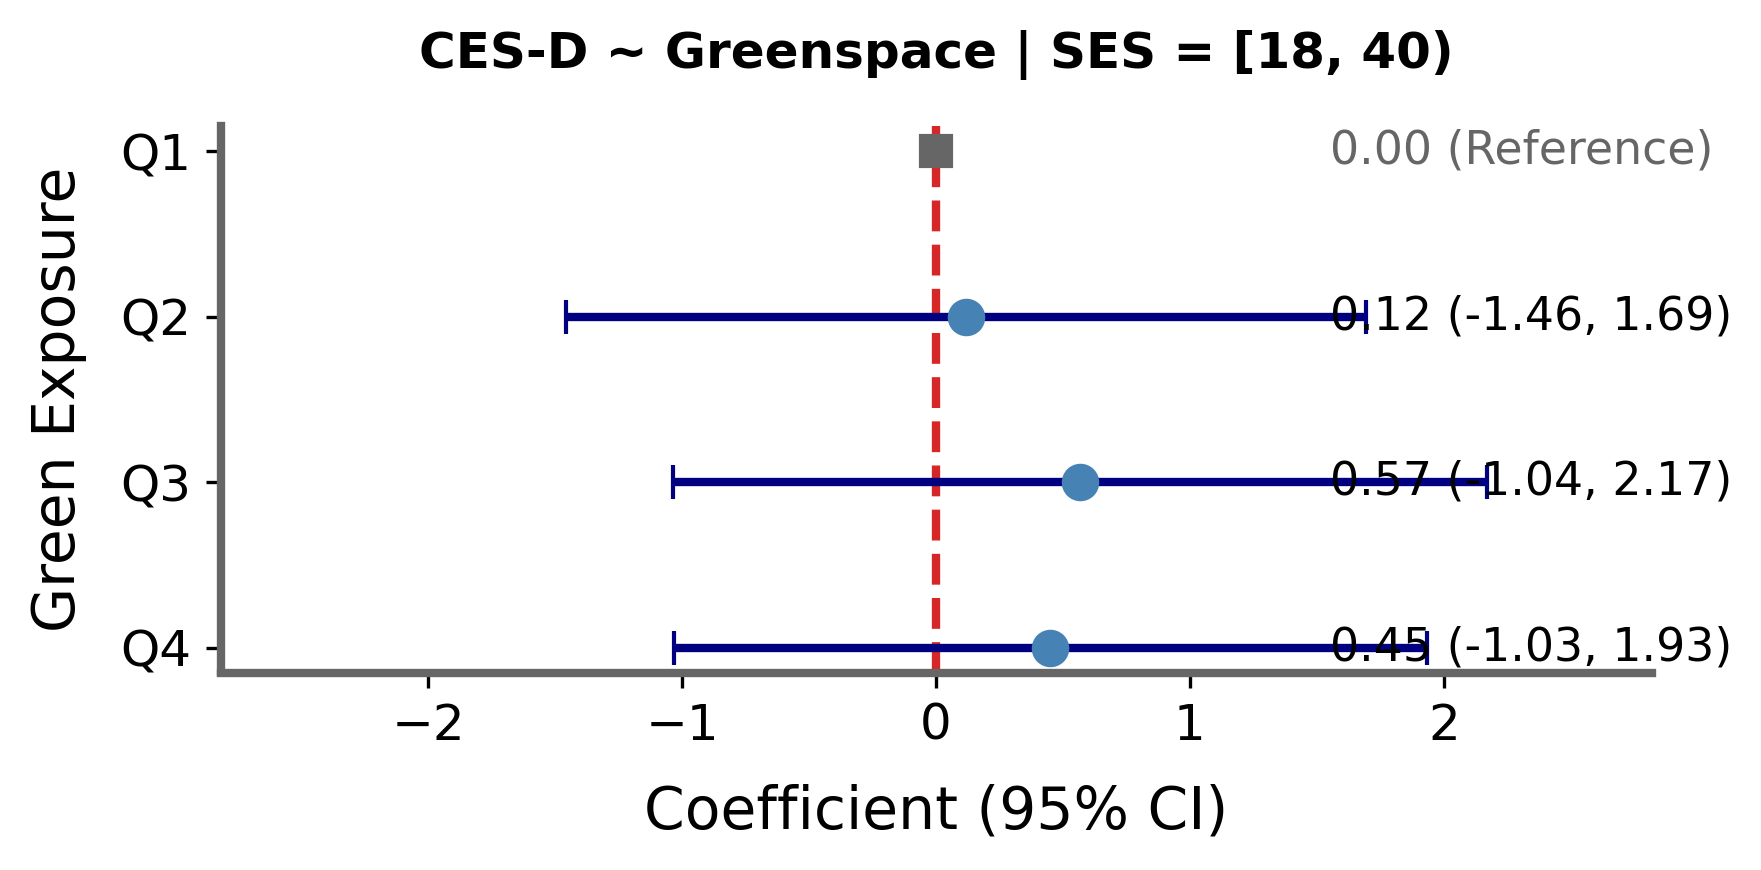

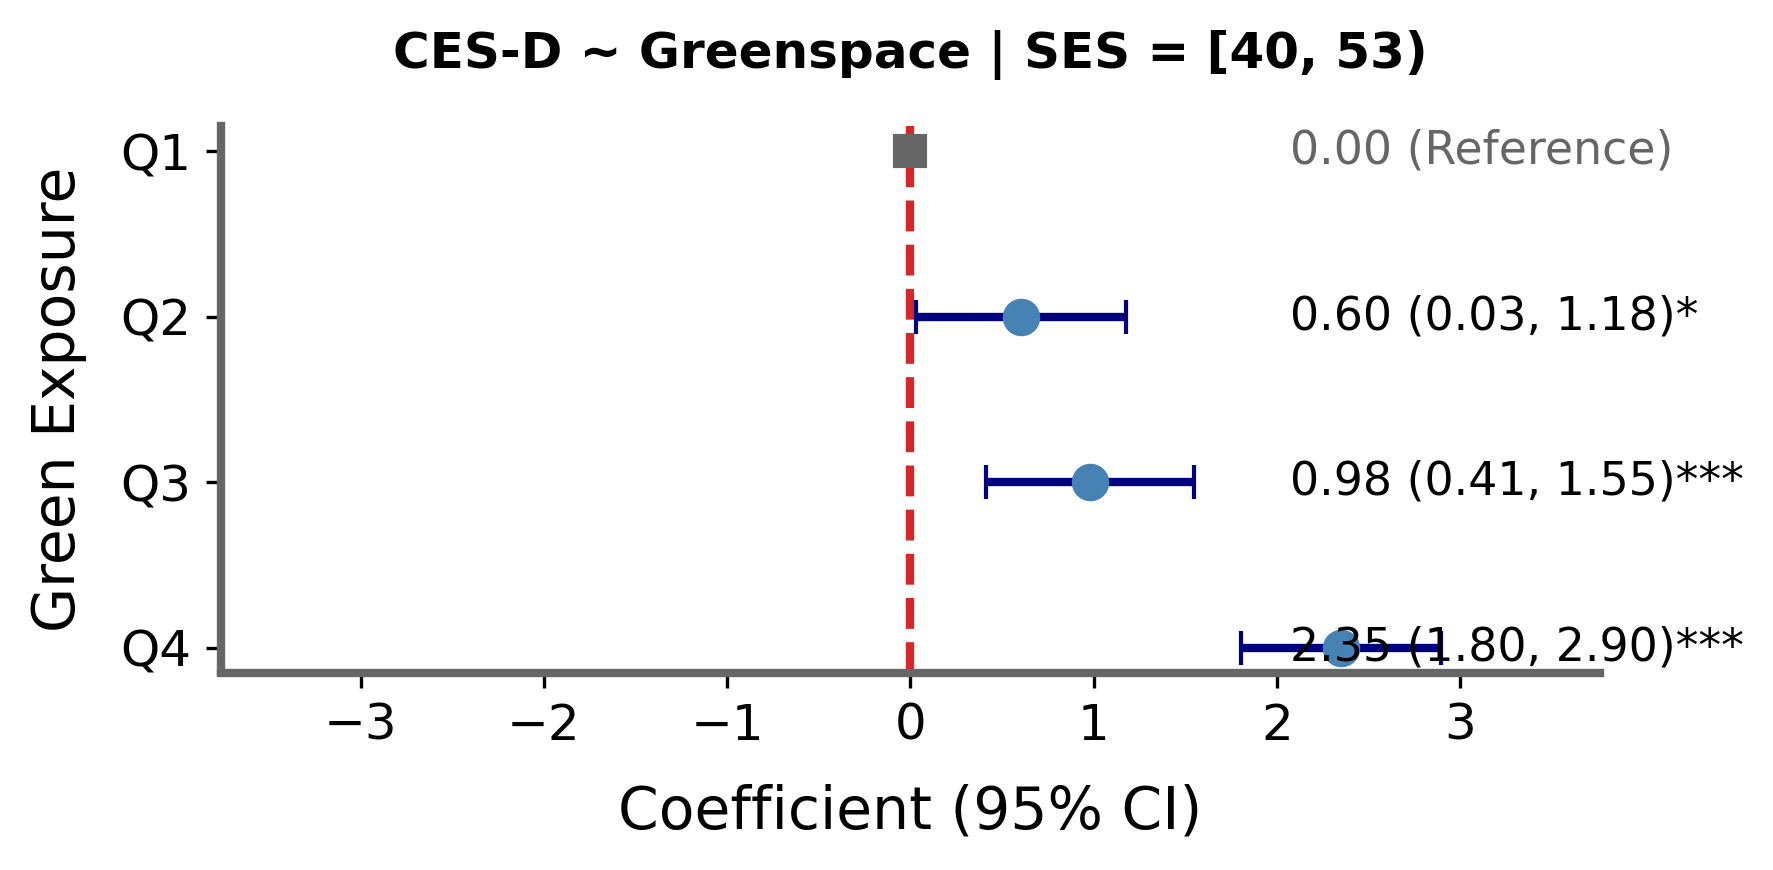

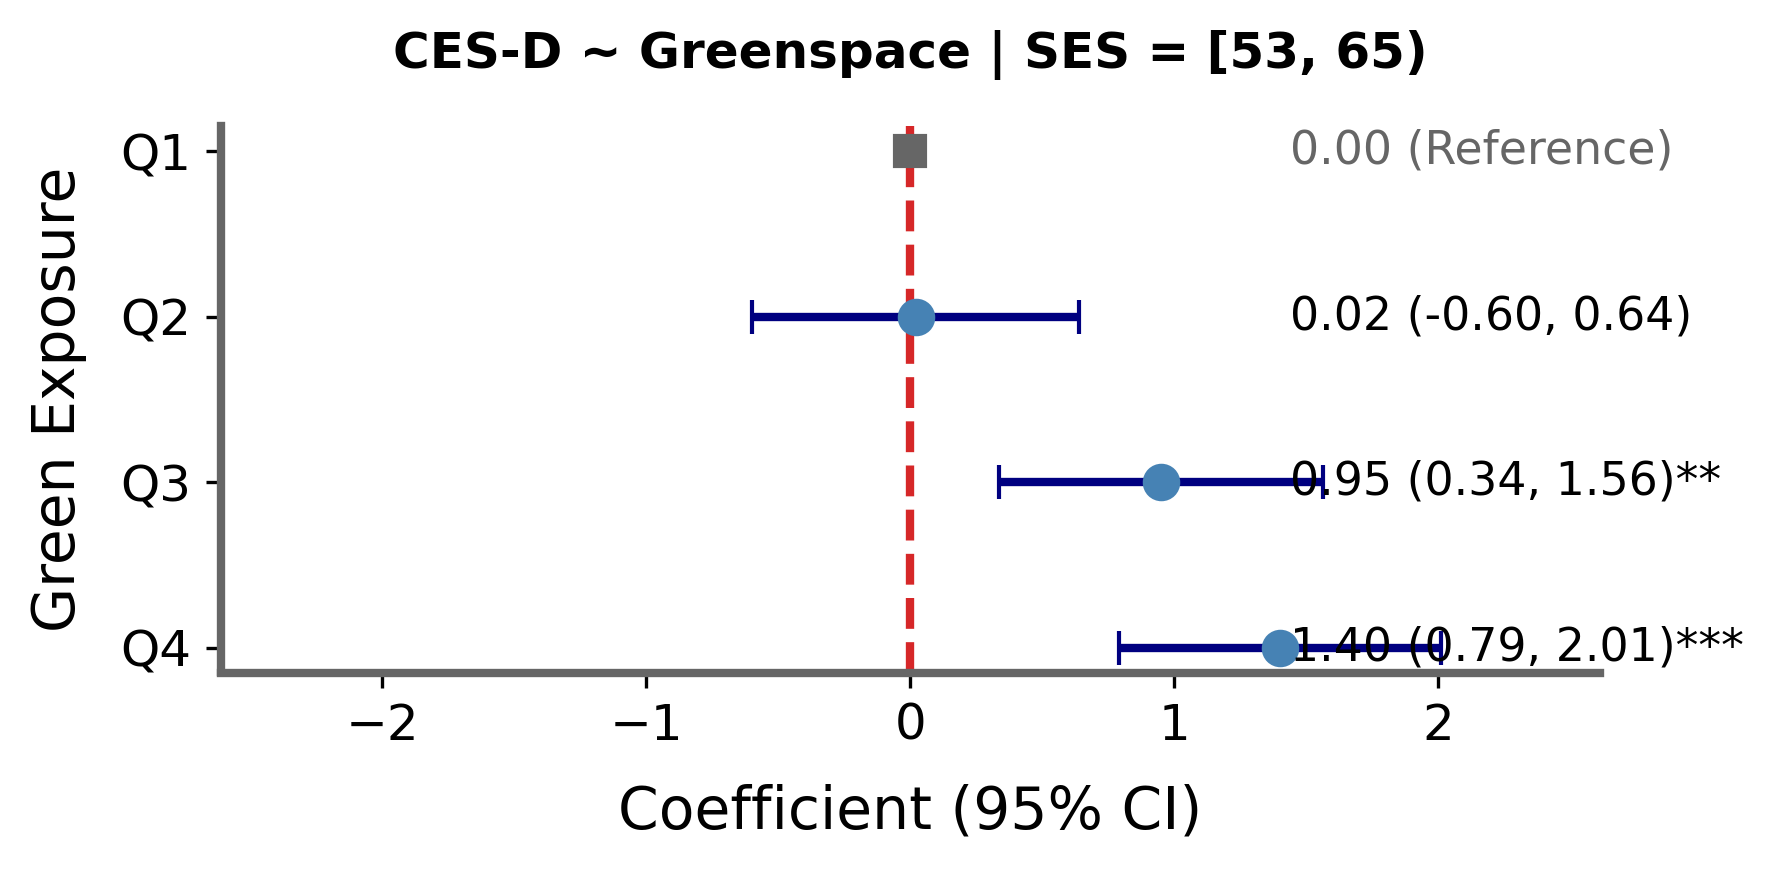

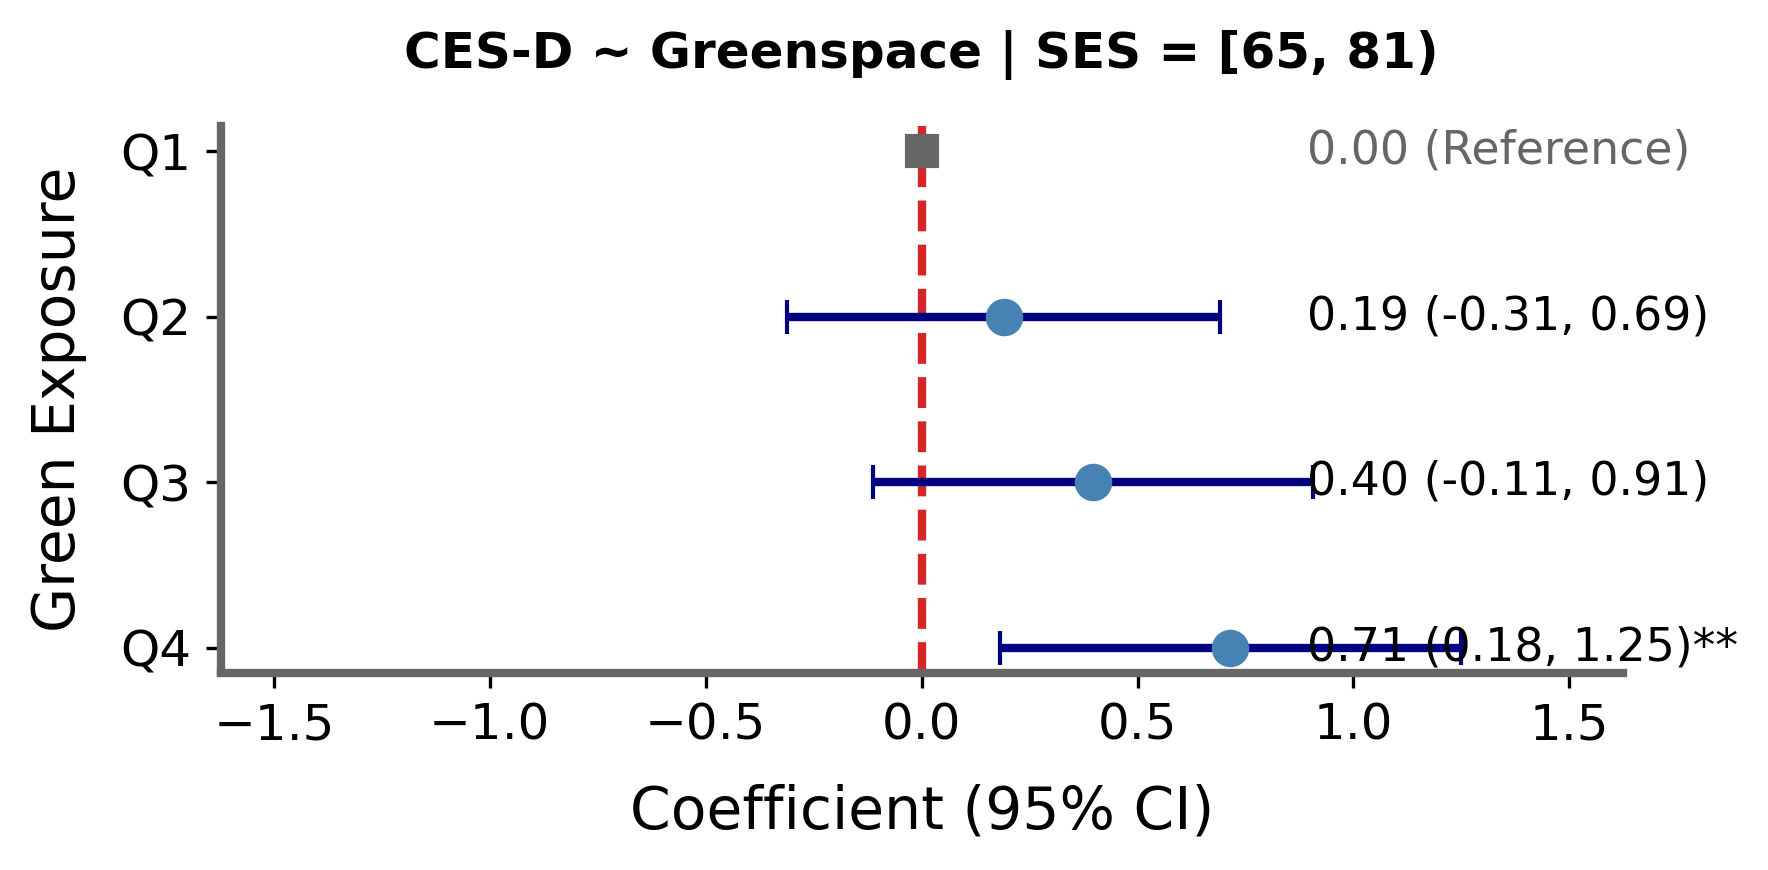

In [58]:
# Forest plot per stratum
for ses, res in strata_results.items():
    linear.plot_forest(
        res["beta_table"],
        title = f"CES-D ~ Greenspace | SES = {ses}",
        predictor_type = "categorical"
    )

# Interaction Linear Model – Experiments

## SES-moderator: Mental Scores across NDVI

In [75]:
data = data_complete.copy()

inter_df, inter_store = experiment.run_interaction_grid(
    data                  = data,
    outcomes              = cols.mental_numeric,
    predictors            = cols.ndvi,
    moderator             = "Socioeconomic Status (Tiers)",
    moderator_type        = "categorical",
#    moderator_reference   = 1.0,
    model_type            = "linear",
    predictor_type        = "continuous",
    scale_predictor       = 0.1,
    outcome_direction_map = outcome_direction_map,
    covariates            = ["Sex", "Age"],
)

columns = ["outcome", "predictor", "n", "moderator", "moderator_level", "scale_predictor", 
           "beta", "beta_95CI", "SE", "p_value_fmt", "covariates", "significant"]

inter_df.query(f"significant == True")[columns]

  [1/12] CES-D Score × NDVI (100m Buffer)  [× Socioeconomic Status (Tiers), linear]
  Interaction fitted | n = 9117 | 0/2 interaction terms p < 0.05
  [2/12] CES-D Score × NDVI (200m Buffer)  [× Socioeconomic Status (Tiers), linear]
  Interaction fitted | n = 9117 | 0/2 interaction terms p < 0.05
  [3/12] CES-D Score × NDVI (500m Buffer)  [× Socioeconomic Status (Tiers), linear]
  Interaction fitted | n = 9117 | 0/2 interaction terms p < 0.05
  [4/12] CES-D Score × NDVI (1000m Buffer)  [× Socioeconomic Status (Tiers), linear]
  Interaction fitted | n = 9117 | 1/2 interaction terms p < 0.05
  [5/12] GAD-7 Score × NDVI (100m Buffer)  [× Socioeconomic Status (Tiers), linear]
  Interaction fitted | n = 9278 | 0/2 interaction terms p < 0.05
  [6/12] GAD-7 Score × NDVI (200m Buffer)  [× Socioeconomic Status (Tiers), linear]
  Interaction fitted | n = 9278 | 0/2 interaction terms p < 0.05
  [7/12] GAD-7 Score × NDVI (500m Buffer)  [× Socioeconomic Status (Tiers), linear]
  Interaction fitted 

,outcome,predictor,n,moderator,moderator_level,scale_predictor,beta,beta_95CI,SE,p_value_fmt,covariates,significant
6,CES-D Score,NDVI (1000m Buffer),9117,Socioeconomic Status (Tiers),2.0,0.1,0.589,"0.589 (0.078, 1.099)",0.261,0.024,"Sex, Age",True
14,GAD-7 Score,NDVI (1000m Buffer),9278,Socioeconomic Status (Tiers),2.0,0.1,0.308,"0.308 (0.062, 0.554)",0.125,0.014,"Sex, Age",True


## Save Interaction Model results to `linear_results` in `pkl` and `csv`

In [76]:
##out_path = f"outputs/linear/interaction_ses/mental_numeric/ndvi/adjusted/linear_results"
##experiment.save_results(inter_df, inter_store, path=out_path)

  Saved pickle : outputs/linear/interaction_ses/mental_numeric/ndvi/adjusted/linear_results.pkl
  Saved CSV    : outputs/linear/interaction_ses/mental_numeric/ndvi/adjusted/linear_results.csv


## SES-moderator: Mental Scores across Green Space Quartiles

In [95]:
data = data_complete.copy()

inter_df, inter_store = experiment.run_interaction_grid(
    data                  = data,
    outcomes              = cols.mental_numeric,
    predictors            = cols.greenspace_quartiles,
    moderator             = "Socioeconomic Status (Tiers)",
    moderator_type        = "categorical",
#    moderator_reference   = 1.0,
    model_type            = "linear",
    predictor_type        = "categorical",
    reference_category    = "1.0",
    label_mapping         = {"1.0": "Q1", "2.0": "Q2", "3.0": "Q3", "4.0": "Q4"},
    outcome_direction_map = outcome_direction_map,
    covariates            = ["Sex", "Age"],
)

columns = ["outcome", "predictor", "n", "moderator", "moderator_level", "reference_level", "level",
           "beta", "beta_95CI", "SE", "p_value_fmt", "covariates", "significant"]

inter_df.query(f"significant == True")[columns]

  [1/12] CES-D Score × Green Space Quartile (100m Buffer)  [× Socioeconomic Status (Tiers), linear]
  Interaction fitted | n = 9079 | 0/6 interaction terms p < 0.05
  [2/12] CES-D Score × Green Space Quartile (200m Buffer)  [× Socioeconomic Status (Tiers), linear]
  Interaction fitted | n = 9079 | 0/6 interaction terms p < 0.05
  [3/12] CES-D Score × Green Space Quartile (500m Buffer)  [× Socioeconomic Status (Tiers), linear]
  Interaction fitted | n = 9079 | 2/6 interaction terms p < 0.05
  [4/12] CES-D Score × Green Space Quartile (1000m Buffer)  [× Socioeconomic Status (Tiers), linear]
  Interaction fitted | n = 9079 | 0/6 interaction terms p < 0.05
  [5/12] GAD-7 Score × Green Space Quartile (100m Buffer)  [× Socioeconomic Status (Tiers), linear]
  Interaction fitted | n = 9238 | 0/6 interaction terms p < 0.05
  [6/12] GAD-7 Score × Green Space Quartile (200m Buffer)  [× Socioeconomic Status (Tiers), linear]
  Interaction fitted | n = 9238 | 0/6 interaction terms p < 0.05
  [7/12] 

,outcome,predictor,n,moderator,moderator_level,reference_level,level,beta,beta_95CI,SE,p_value_fmt,covariates,significant
14,CES-D Score,Green Space Quartile (500m Buffer),9079,Socioeconomic Status (Tiers),2.0,Q1,Q4,1.615,"1.615 (0.534, 2.696)",0.551,0.003,"Sex, Age",True
17,CES-D Score,Green Space Quartile (500m Buffer),9079,Socioeconomic Status (Tiers),3.0,Q1,Q4,1.600,"1.600 (0.330, 2.871)",0.648,0.014,"Sex, Age",True
38,GAD-7 Score,Green Space Quartile (500m Buffer),9238,Socioeconomic Status (Tiers),2.0,Q1,Q4,0.905,"0.905 (0.384, 1.426)",0.266,<0.001,"Sex, Age",True
41,GAD-7 Score,Green Space Quartile (500m Buffer),9238,Socioeconomic Status (Tiers),3.0,Q1,Q4,0.755,"0.755 (0.142, 1.368)",0.313,0.016,"Sex, Age",True
43,GAD-7 Score,Green Space Quartile (1000m Buffer),9238,Socioeconomic Status (Tiers),2.0,Q1,Q3,0.552,"0.552 (0.052, 1.053)",0.255,0.031,"Sex, Age",True
46,GAD-7 Score,Green Space Quartile (1000m Buffer),9238,Socioeconomic Status (Tiers),3.0,Q1,Q3,0.642,"0.642 (0.038, 1.246)",0.308,0.037,"Sex, Age",True
60,SWLS Score,Green Space Quartile (500m Buffer),9257,Socioeconomic Status (Tiers),2.0,Q1,Q2,0.821,"0.821 (0.059, 1.582)",0.389,0.035,"Sex, Age",True


## Save Interaction Model results to `linear_results` in `pkl` and `csv`

In [96]:
##out_path = f"outputs/linear/interaction_ses/mental_numeric/quartiles/adjusted/linear_results"
##experiment.save_results(inter_df, inter_store, path=out_path)

  Saved pickle : outputs/linear/interaction_ses/mental_numeric/quartiles/adjusted/linear_results.pkl
  Saved CSV    : outputs/linear/interaction_ses/mental_numeric/quartiles/adjusted/linear_results.csv


# Analysis – SES-Moderator Linear Model

## Mental Scores vs. NDVI – unadjusted

In [103]:
out_path = f"outputs/linear/interaction_ses/mental_numeric/ndvi/unadjusted/linear_results"
inter_df, inter_store = experiment.load_results(out_path)

columns = ["outcome", "predictor", "n", "moderator", "moderator_level", "scale_predictor", 
           "beta", "beta_95CI", "SE", "p_value_fmt", "covariates", "significant"]

inter_df.query(f"significant == True")[columns]

#outcome = cols.mental_numeric
#predictor = cols.ndvi[2]
#inter_df.query(f"outcome == @outcome and predictor == @predictor")[columns]

  Loaded results saved at: 2026-07-27T16:16:51.381228


,outcome,predictor,n,moderator,moderator_level,scale_predictor,beta,beta_95CI,SE,p_value_fmt,covariates,significant
6,CES-D Score,NDVI (1000m Buffer),9117,Socioeconomic Status (Tiers),2.0,0.1,0.570,"0.570 (0.055, 1.085)",0.262,0.030,unadjusted,True
14,GAD-7 Score,NDVI (1000m Buffer),9278,Socioeconomic Status (Tiers),2.0,0.1,0.306,"0.306 (0.057, 0.555)",0.127,0.016,unadjusted,True


## Mental Scores vs. NDVI – adjusted: Sex, Age

In [104]:
out_path = f"outputs/linear/interaction_ses/mental_numeric/ndvi/adjusted/linear_results"
inter_df, inter_store = experiment.load_results(out_path)

columns = ["outcome", "predictor", "n", "moderator", "moderator_level", "scale_predictor", 
           "beta", "beta_95CI", "SE", "p_value_fmt", "covariates", "significant"]

inter_df.query(f"significant == True")[columns]

#outcome = cols.mental_numeric
#predictor = cols.ndvi[2]
#inter_df.query(f"outcome == @outcome and predictor == @predictor")[columns]

  Loaded results saved at: 2026-07-27T16:17:48.852352


,outcome,predictor,n,moderator,moderator_level,scale_predictor,beta,beta_95CI,SE,p_value_fmt,covariates,significant
6,CES-D Score,NDVI (1000m Buffer),9117,Socioeconomic Status (Tiers),2.0,0.1,0.589,"0.589 (0.078, 1.099)",0.261,0.024,"Sex, Age",True
14,GAD-7 Score,NDVI (1000m Buffer),9278,Socioeconomic Status (Tiers),2.0,0.1,0.308,"0.308 (0.062, 0.554)",0.125,0.014,"Sex, Age",True


## Mental Scores vs. Land-use-based Quartiles – unadjusted

In [105]:
out_path = f"outputs/linear/interaction_ses/mental_numeric/quartiles/unadjusted/linear_results"
inter_df, inter_store = experiment.load_results(out_path)

columns = ["outcome", "predictor", "n", "moderator", "moderator_level", "reference_level", "level",
           "beta", "beta_95CI", "SE", "p_value_fmt", "covariates", "significant"]

inter_df.query(f"significant == True")[columns]

#outcome = cols.mental_numeric
#predictor = cols.ndvi[2]
#inter_df.query(f"outcome == @outcome and predictor == @predictor and level == 'Q4'")[columns]

  Loaded results saved at: 2026-07-27T16:29:19.879044


,outcome,predictor,n,moderator,moderator_level,reference_level,level,beta,beta_95CI,SE,p_value_fmt,covariates,significant
14,CES-D Score,Green Space Quartile (500m Buffer),9079,Socioeconomic Status (Tiers),2.0,Q1,Q4,1.622,"1.622 (0.533, 2.710)",0.555,0.004,unadjusted,True
17,CES-D Score,Green Space Quartile (500m Buffer),9079,Socioeconomic Status (Tiers),3.0,Q1,Q4,1.678,"1.678 (0.399, 2.957)",0.653,0.010,unadjusted,True
38,GAD-7 Score,Green Space Quartile (500m Buffer),9238,Socioeconomic Status (Tiers),2.0,Q1,Q4,0.936,"0.936 (0.408, 1.464)",0.269,<0.001,unadjusted,True
41,GAD-7 Score,Green Space Quartile (500m Buffer),9238,Socioeconomic Status (Tiers),3.0,Q1,Q4,0.854,"0.854 (0.234, 1.475)",0.317,0.007,unadjusted,True
43,GAD-7 Score,Green Space Quartile (1000m Buffer),9238,Socioeconomic Status (Tiers),2.0,Q1,Q3,0.588,"0.588 (0.081, 1.095)",0.259,0.023,unadjusted,True
46,GAD-7 Score,Green Space Quartile (1000m Buffer),9238,Socioeconomic Status (Tiers),3.0,Q1,Q3,0.669,"0.669 (0.058, 1.281)",0.312,0.032,unadjusted,True
60,SWLS Score,Green Space Quartile (500m Buffer),9257,Socioeconomic Status (Tiers),2.0,Q1,Q2,0.818,"0.818 (0.051, 1.585)",0.391,0.037,unadjusted,True


## Mental Scores vs. Land-use-based Quartiles – adjusted: Sex, Age

In [106]:
out_path = f"outputs/linear/interaction_ses/mental_numeric/quartiles/adjusted/linear_results"
inter_df, inter_store = experiment.load_results(out_path)

columns = ["outcome", "predictor", "n", "moderator", "moderator_level", "reference_level", "level",
           "beta", "beta_95CI", "SE", "p_value_fmt", "covariates", "significant"]

inter_df.query(f"significant == True")[columns]

#outcome = cols.mental_numeric
#predictor = cols.ndvi[2]
#inter_df.query(f"outcome == @outcome and predictor == @predictor and level == 'Q4'")[columns]

  Loaded results saved at: 2026-07-27T16:29:45.715631


,outcome,predictor,n,moderator,moderator_level,reference_level,level,beta,beta_95CI,SE,p_value_fmt,covariates,significant
14,CES-D Score,Green Space Quartile (500m Buffer),9079,Socioeconomic Status (Tiers),2.0,Q1,Q4,1.615,"1.615 (0.534, 2.696)",0.551,0.003,"Sex, Age",True
17,CES-D Score,Green Space Quartile (500m Buffer),9079,Socioeconomic Status (Tiers),3.0,Q1,Q4,1.600,"1.600 (0.330, 2.871)",0.648,0.014,"Sex, Age",True
38,GAD-7 Score,Green Space Quartile (500m Buffer),9238,Socioeconomic Status (Tiers),2.0,Q1,Q4,0.905,"0.905 (0.384, 1.426)",0.266,<0.001,"Sex, Age",True
41,GAD-7 Score,Green Space Quartile (500m Buffer),9238,Socioeconomic Status (Tiers),3.0,Q1,Q4,0.755,"0.755 (0.142, 1.368)",0.313,0.016,"Sex, Age",True
43,GAD-7 Score,Green Space Quartile (1000m Buffer),9238,Socioeconomic Status (Tiers),2.0,Q1,Q3,0.552,"0.552 (0.052, 1.053)",0.255,0.031,"Sex, Age",True
46,GAD-7 Score,Green Space Quartile (1000m Buffer),9238,Socioeconomic Status (Tiers),3.0,Q1,Q3,0.642,"0.642 (0.038, 1.246)",0.308,0.037,"Sex, Age",True
60,SWLS Score,Green Space Quartile (500m Buffer),9257,Socioeconomic Status (Tiers),2.0,Q1,Q2,0.821,"0.821 (0.059, 1.582)",0.389,0.035,"Sex, Age",True


# Analysis – Age-Moderator Linear Model

## Mental Scores vs. NDVI – unadjusted

In [107]:
out_path = f"outputs/linear/interaction_age/mental_numeric/ndvi/unadjusted/linear_results"
inter_df, inter_store = experiment.load_results(out_path)

columns = ["outcome", "predictor", "n", "moderator", "moderator_level", "scale_predictor", 
           "beta", "beta_95CI", "SE", "p_value_fmt", "covariates", "significant"]

inter_df.query(f"significant == True")[columns]

#outcome = cols.mental_numeric
#predictor = cols.ndvi[2]
#inter_df.query(f"outcome == @outcome and predictor == @predictor")[columns]

  Loaded results saved at: 2026-07-27T16:15:31.716772


,outcome,predictor,n,moderator,moderator_level,scale_predictor,beta,beta_95CI,SE,p_value_fmt,covariates,significant


## Mental Scores vs. NDVI – adjusted: Sex, SES

In [108]:
out_path = f"outputs/linear/interaction_age/mental_numeric/ndvi/adjusted/linear_results"
inter_df, inter_store = experiment.load_results(out_path)

columns = ["outcome", "predictor", "n", "moderator", "moderator_level", "scale_predictor", 
           "beta", "beta_95CI", "SE", "p_value_fmt", "covariates", "significant"]

inter_df.query(f"significant == True")[columns]

#outcome = cols.mental_numeric
#predictor = cols.ndvi[2]
#inter_df.query(f"outcome == @outcome and predictor == @predictor")[columns]

  Loaded results saved at: 2026-07-27T16:15:47.279660


,outcome,predictor,n,moderator,moderator_level,scale_predictor,beta,beta_95CI,SE,p_value_fmt,covariates,significant


## Mental Scores vs. Land-use-based Quartiles – unadjusted

In [109]:
out_path = f"outputs/linear/interaction_age/mental_numeric/quartiles/unadjusted/linear_results"
inter_df, inter_store = experiment.load_results(out_path)

columns = ["outcome", "predictor", "n", "moderator", "moderator_level", "reference_level", "level",
           "beta", "beta_95CI", "SE", "p_value_fmt", "covariates", "significant"]

inter_df.query(f"significant == True")[columns]

#outcome = cols.mental_numeric
#predictor = cols.ndvi[2]
#inter_df.query(f"outcome == @outcome and predictor == @predictor and level == 'Q4'")[columns]

  Loaded results saved at: 2026-07-27T16:27:43.293670


,outcome,predictor,n,moderator,moderator_level,reference_level,level,beta,beta_95CI,SE,p_value_fmt,covariates,significant
11,CES-D Score,Green Space Quartile (200m Buffer),9104,Age_group,"[40, 53)",Q1,Q4,-2.629,"-2.629 (-4.692, -0.566)",1.052,0.013,unadjusted,True
14,CES-D Score,Green Space Quartile (200m Buffer),9104,Age_group,"[53, 65)",Q1,Q4,-3.066,"-3.066 (-5.166, -0.967)",1.071,0.004,unadjusted,True
17,CES-D Score,Green Space Quartile (200m Buffer),9104,Age_group,"[65, 81)",Q1,Q4,-2.570,"-2.570 (-4.675, -0.466)",1.074,0.017,unadjusted,True
20,CES-D Score,Green Space Quartile (500m Buffer),9104,Age_group,"[40, 53)",Q1,Q4,-2.865,"-2.865 (-4.892, -0.838)",1.034,0.006,unadjusted,True
26,CES-D Score,Green Space Quartile (500m Buffer),9104,Age_group,"[65, 81)",Q1,Q4,-2.105,"-2.105 (-4.168, -0.041)",1.053,0.046,unadjusted,True
47,GAD-7 Score,Green Space Quartile (200m Buffer),9264,Age_group,"[40, 53)",Q1,Q4,-1.193,"-1.193 (-2.177, -0.210)",0.502,0.017,unadjusted,True
50,GAD-7 Score,Green Space Quartile (200m Buffer),9264,Age_group,"[53, 65)",Q1,Q4,-1.256,"-1.256 (-2.257, -0.255)",0.511,0.014,unadjusted,True
53,GAD-7 Score,Green Space Quartile (200m Buffer),9264,Age_group,"[65, 81)",Q1,Q4,-1.007,"-1.007 (-2.010, -0.003)",0.512,0.049,unadjusted,True
92,SWLS Score,Green Space Quartile (500m Buffer),9283,Age_group,"[40, 53)",Q1,Q4,1.901,"1.901 (0.335, 3.466)",0.799,0.017,unadjusted,True


## Mental Scores vs. Land-use-based Quartiles – adjusted: Sex, SES

In [110]:
out_path = f"outputs/linear/interaction_age/mental_numeric/quartiles/adjusted/linear_results"
inter_df, inter_store = experiment.load_results(out_path)

columns = ["outcome", "predictor", "n", "moderator", "moderator_level", "reference_level", "level",
           "beta", "beta_95CI", "SE", "p_value_fmt", "covariates", "significant"]

inter_df.query(f"significant == True")[columns]

#outcome = cols.mental_numeric
#predictor = cols.ndvi[2]
#inter_df.query(f"outcome == @outcome and predictor == @predictor and level == 'Q4'")[columns]

  Loaded results saved at: 2026-07-27T16:28:17.171357


,outcome,predictor,n,moderator,moderator_level,reference_level,level,beta,beta_95CI,SE,p_value_fmt,covariates,significant
11,CES-D Score,Green Space Quartile (200m Buffer),9079,Age_group,"[40, 53)",Q1,Q4,-2.357,"-2.357 (-4.382, -0.332)",1.033,0.023,"Sex, Socioeconomic Status (Tiers)",True
14,CES-D Score,Green Space Quartile (200m Buffer),9079,Age_group,"[53, 65)",Q1,Q4,-2.597,"-2.597 (-4.657, -0.538)",1.051,0.013,"Sex, Socioeconomic Status (Tiers)",True
17,CES-D Score,Green Space Quartile (200m Buffer),9079,Age_group,"[65, 81)",Q1,Q4,-2.127,"-2.127 (-4.192, -0.061)",1.054,0.044,"Sex, Socioeconomic Status (Tiers)",True
20,CES-D Score,Green Space Quartile (500m Buffer),9079,Age_group,"[40, 53)",Q1,Q4,-2.784,"-2.784 (-4.762, -0.806)",1.009,0.006,"Sex, Socioeconomic Status (Tiers)",True
26,CES-D Score,Green Space Quartile (500m Buffer),9079,Age_group,"[65, 81)",Q1,Q4,-2.102,"-2.102 (-4.116, -0.089)",1.027,0.041,"Sex, Socioeconomic Status (Tiers)",True
47,GAD-7 Score,Green Space Quartile (200m Buffer),9238,Age_group,"[40, 53)",Q1,Q4,-1.047,"-1.047 (-2.030, -0.063)",0.502,0.037,"Sex, Socioeconomic Status (Tiers)",True
50,GAD-7 Score,Green Space Quartile (200m Buffer),9238,Age_group,"[53, 65)",Q1,Q4,-1.105,"-1.105 (-2.105, -0.105)",0.510,0.030,"Sex, Socioeconomic Status (Tiers)",True
92,SWLS Score,Green Space Quartile (500m Buffer),9257,Age_group,"[40, 53)",Q1,Q4,1.736,"1.736 (0.200, 3.271)",0.783,0.027,"Sex, Socioeconomic Status (Tiers)",True


# Analysis – Sex-Moderator Linear Model

## Mental Scores vs. NDVI – unadjusted

In [111]:
out_path = f"outputs/linear/interaction_sex/mental_numeric/ndvi/unadjusted/linear_results"
inter_df, inter_store = experiment.load_results(out_path)

columns = ["outcome", "predictor", "n", "moderator", "moderator_level", "scale_predictor", 
           "beta", "beta_95CI", "SE", "p_value_fmt", "covariates", "significant"]

inter_df.query(f"significant == True")[columns]

#outcome = cols.mental_numeric
#predictor = cols.ndvi[2]
#inter_df.query(f"outcome == @outcome and predictor == @predictor")[columns]

  Loaded results saved at: 2026-07-27T16:11:15.435435


,outcome,predictor,n,moderator,moderator_level,scale_predictor,beta,beta_95CI,SE,p_value_fmt,covariates,significant


## Mental Scores vs. NDVI – adjusted: Sex, SES

In [112]:
out_path = f"outputs/linear/interaction_sex/mental_numeric/ndvi/adjusted/linear_results"
inter_df, inter_store = experiment.load_results(out_path)

columns = ["outcome", "predictor", "n", "moderator", "moderator_level", "scale_predictor", 
           "beta", "beta_95CI", "SE", "p_value_fmt", "covariates", "significant"]

inter_df.query(f"significant == True")[columns]

#outcome = cols.mental_numeric
#predictor = cols.ndvi[2]
#inter_df.query(f"outcome == @outcome and predictor == @predictor")[columns]

  Loaded results saved at: 2026-07-27T16:11:36.243230


,outcome,predictor,n,moderator,moderator_level,scale_predictor,beta,beta_95CI,SE,p_value_fmt,covariates,significant


## Mental Scores vs. Land-use-based Quartiles – unadjusted

In [113]:
out_path = f"outputs/linear/interaction_sex/mental_numeric/quartiles/unadjusted/linear_results"
inter_df, inter_store = experiment.load_results(out_path)

columns = ["outcome", "predictor", "n", "moderator", "moderator_level", "reference_level", "level",
           "beta", "beta_95CI", "SE", "p_value_fmt", "covariates", "significant"]

inter_df.query(f"significant == True")[columns]

#outcome = cols.mental_numeric
#predictor = cols.ndvi[2]
#inter_df.query(f"outcome == @outcome and predictor == @predictor and level == 'Q4'")[columns]

  Loaded results saved at: 2026-07-27T16:23:19.218333


,outcome,predictor,n,moderator,moderator_level,reference_level,level,beta,beta_95CI,SE,p_value_fmt,covariates,significant
25,SWLS Score,Green Space Quartile (100m Buffer),9283,Sex,1,Q1,Q3,-0.691,"-0.691 (-1.329, -0.053)",0.325,0.034,unadjusted,True


## Mental Scores vs. Land-use-based Quartiles – adjusted: Sex, SES

In [114]:
out_path = f"outputs/linear/interaction_sex/mental_numeric/quartiles/adjusted/linear_results"
inter_df, inter_store = experiment.load_results(out_path)

columns = ["outcome", "predictor", "n", "moderator", "moderator_level", "reference_level", "level",
           "beta", "beta_95CI", "SE", "p_value_fmt", "covariates", "significant"]

inter_df.query(f"significant == True")[columns]

#outcome = cols.mental_numeric
#predictor = cols.ndvi[2]
#inter_df.query(f"outcome == @outcome and predictor == @predictor and level == 'Q4'")[columns]

  Loaded results saved at: 2026-07-27T16:23:31.978385


,outcome,predictor,n,moderator,moderator_level,reference_level,level,beta,beta_95CI,SE,p_value_fmt,covariates,significant


# Interaction Linear Model – Single Mental Health Variable

In [100]:
data = data_complete.copy()

result, meta, interaction_table = linear.fit_interaction(
    data                = data,
    outcome             = "SWLS Score", #"CES-D Score",
    predictor           = "NDVI (500m Buffer)", #"Green Space Quartile (500m Buffer)",
    moderator           = "Socioeconomic Status (Tiers)",
    moderator_type      = "categorical",
#    moderator_reference = 1.0, # low SES as reference
    predictor_type      = "continuous",
    scale_predictor     = 0.1,
#    reference_category  = "1.0",
#    label_mapping       = {"1.0": "Q1", "2.0": "Q2", "3.0": "Q3", "4.0": "Q4"},
    #covariates          = ["Age", "Sex"],
)

display(interaction_table)

  Interaction fitted | n = 9297 | 0/2 interaction terms p < 0.05


,outcome,predictor,predictor_type,moderator,scale_predictor,reference_level,level,moderator_level,beta,SE,CI_lower,CI_upper,beta_95CI,p_value,p_value_fmt,covariates,significant
0,SWLS Score,NDVI (500m Buffer),continuous,Socioeconomic Status (Tiers),0.1,None,NDVI (500m Buffer),2.0,0.146,0.190,-0.226,0.519,"0.146 (-0.226, 0.519)",0.441654,0.442,unadjusted,False
1,SWLS Score,NDVI (500m Buffer),continuous,Socioeconomic Status (Tiers),0.1,None,NDVI (500m Buffer),3.0,-0.192,0.223,-0.629,0.245,"-0.192 (-0.629, 0.245)",0.388602,0.389,unadjusted,False
